# Validation on veer-only cases

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pathlib import Path
from wrf_io import postproc
from itertools import product
from MITRotor import IEA10MW

In [3]:
save_path = '/scratch/09909/smata/induction_modeling/les_bem_validation/noShearAllVeer/'

In [4]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [5]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

In [6]:
fontsize = 20
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 
plt.rcParams['figure.dpi']      = 300

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [7]:
casenames = [
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200'
]

In [8]:
wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/'+casenames[count]+'_lite.npz')))

In [9]:
def rotor_average(f, r, theta):
    dr = np.gradient(r)
    dtheta = np.gradient(theta)

    area_elements = np.outer(dr * r, dtheta)
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)

    area_avg = np.sum(integrand) / A

    return area_avg

In [10]:
def annulus_average(f, theta):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(f * weights, axis=1)

    return X_azim

In [11]:
def annulus_to_rotor_average(f, r):

    dr = np.gradient(r)
    area_elements = 2 * np.pi * r * dr  # differential area for annular rings
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)  # total area of annulus from R1 to R2

    X_rotor =  np.sum(integrand) / A

    return X_rotor

In [ ]:
Nelm = wrfles_bem[0]['Nelm']
Nsct = wrfles_bem[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles_bem[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['radius'] + z_hh

wrf_ind      = np.zeros((Nelm, Nsct, len(casenames)))
wrf_cot      = np.zeros((Nelm, Nsct, len(casenames)))

wrf_tsr      = np.zeros(len(casenames), dtype=float)
wrf_omg      = np.zeros(len(casenames), dtype=float)

wrf_cax      = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vax_real = np.zeros((Nelm, Nsct, len(casenames)))
wrf_vtn_real = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vax      = np.zeros((Nelm, Nsct, len(casenames)))
wrf_vtn      = np.zeros((Nelm, Nsct, len(casenames)))
wrf_vtn_K     = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vax_original = np.zeros((Nelm, Nsct, len(casenames)))
wrf_vtn_original = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vax_w_U = np.zeros((Nelm, Nsct, len(casenames)))
wrf_vtn_w_U_and_w = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vax_w_U_simp = np.zeros((Nelm, Nsct, len(casenames)))
wrf_vtn_w_U_and_w_simp = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vtn_w_U_simp = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vtn_K_t     = np.zeros(len(casenames), dtype=float)
wrf_vtn_D_t     = np.zeros(len(casenames), dtype=float)

wrf_vtn_K_1     = np.zeros(len(casenames), dtype=float)
wrf_vtn_K_2     = np.zeros(len(casenames), dtype=float)
wrf_vtn_K_3     = np.zeros(len(casenames), dtype=float)

wrf_vtn_D     = np.zeros((Nelm, Nsct, len(casenames)))

wrf_vtn_D_1     = np.zeros(len(casenames), dtype=float)
wrf_vtn_D_2     = np.zeros(len(casenames), dtype=float)
wrf_vtn_D_3     = np.zeros(len(casenames), dtype=float)
wrf_vtn_real_t     = np.zeros(len(casenames), dtype=float)

wrf_CL       = np.zeros((Nelm, Nsct, len(casenames)))
wrf_CD       = np.zeros((Nelm, Nsct, len(casenames)))

wrf_CL_real  = np.zeros((Nelm, Nsct, len(casenames)))
wrf_CD_real  = np.zeros((Nelm, Nsct, len(casenames)))

wrf_L_real   = np.zeros((Nelm, Nsct, len(casenames)))
wrf_D_real   = np.zeros((Nelm, Nsct, len(casenames)))

wrf_FN_real  = np.zeros((Nelm, Nsct, len(casenames)))
wrf_FT_real  = np.zeros((Nelm, Nsct, len(casenames)))

wrf_phi      = np.zeros((Nelm, Nsct, len(casenames)))

wrf_phi_real = np.zeros((Nelm, Nsct, len(casenames)))

wrf_aoa      = np.zeros((Nelm, Nsct, len(casenames)))

wrf_aoa_real = np.zeros((Nelm, Nsct, len(casenames)))

wrf_pow_real = np.zeros(len(casenames), dtype=float)
wrf_thr_real = np.zeros(len(casenames), dtype=float)

U_loc        = np.zeros((Nelm, Nsct, len(casenames)))
dir_loc      = np.zeros((Nelm, Nsct, len(casenames)))

u            = np.zeros((Nelm, Nsct, len(casenames)))
v            = np.zeros((Nelm, Nsct, len(casenames)))
wrf_W        = np.zeros((Nelm, Nsct, len(casenames)))

wrf_W_real   = np.zeros((Nelm, Nsct, len(casenames)))

shapiro      = np.zeros(len(casenames), dtype=float)

Uhub         = np.zeros(len(casenames), dtype=float)

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles_bem[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    # u_rotor = np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0)
    u_rotor = np.mean(wrfles_bem[count]['u'],axis=0)
    v_rotor = np.mean(wrfles_bem[count]['v'],axis=0)
    w_rotor = np.mean(wrfles_bem[count]['w'],axis=0)

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles_bem[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles_bem[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Induction
    a_ax = 1 - u_rotor/U_hub
    # a_bar = 0

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma = (3 * chord) / (2 * np.pi * r_mat * R)

    # Tip speed ratio
    tsr = np.mean(wrfles_bem[count]['omega']*R*2*np.pi/(U_hub*60), axis=0) 

    aprime = 0

    trbYaw = 0

    Vax_original = (
        u_rotor / U_hub * np.cos(trbYaw) + 
        v_rotor / U_hub * np.sin(trbYaw)
    )

    Vax_w_U = (
        U * (1 - a_ax) / U_hub * np.cos(wdir) * np.cos(trbYaw) + 
        U * (1 - a_ax) / U_hub * np.sin(wdir) * np.sin(trbYaw)
    )

    Vax_w_U_simp = (
        U * (1 - a_ax) / U_hub * np.cos(wdir - trbYaw)
    )

    Vtn_original = (
        (u_rotor / U_hub * np.cos(trbYaw) + 
        v_rotor / U_hub * np.sin(trbYaw)) * np.cos(theta) - 
        w_rotor / U_hub * np.sin(theta)
    )

    Vtn_w_U_and_w = (
        (U * (1 - a_ax) / U_hub * np.cos(wdir) * np.cos(trbYaw) + 
        U * (1 - a_ax) / U_hub * np.sin(wdir) * np.sin(trbYaw)) * np.cos(theta) - 
        w_rotor / U_hub * np.sin(theta)
    )

    Vtn_w_U_and_w_simp = (
        (U * (1 - a_ax) / U_hub) * np.cos(wdir - trbYaw) * np.cos(theta) - 
        (w_rotor / U_hub) * np.sin(theta)
    )

    Vtn_w_U_simp = (
        (U * (1 - a_ax) 
        / U_hub) * np.cos(wdir - trbYaw) * np.cos(theta)
    )

    wrf_vax_original[:,:,count]       = Vax_original 
    wrf_vtn_original[:,:,count]       = Vtn_original

    wrf_vax_w_U[:,:,count]            = Vax_w_U
    wrf_vtn_w_U_and_w[:,:,count]      = Vtn_w_U_and_w

    wrf_vax_w_U_simp[:,:,count]       = Vax_w_U_simp
    wrf_vtn_w_U_and_w_simp[:,:,count] = Vtn_w_U_and_w_simp

    wrf_vtn_w_U_simp[:,:,count]       = Vtn_w_U_simp

    # Relative velocity
    # W = np.sqrt(Vax**2 + Vtan**2)

    W = np.zeros_like(Vax_w_U)
    phi = np.zeros_like(Vax_w_U)

    # Inflow angle
    # phi = np.atan2(Vax,Vtan)

    aoa  = phi - twist[:, np.newaxis]
    # aoa  = np.deg2rad(np.mean(wrfles_bem[count]['aoa'], axis=0))
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial force coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax

    # Store variables
    u[:,:,count]            = u_rotor
    v[:,:,count]            = v_rotor

    U_loc[:,:,count]        = U/U_hub
    dir_loc[:,:,count]      = wdir

    wrf_L_real[:,:,count]   = np.mean(wrfles_bem[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles_bem[count]['d'], axis=0)

    wrf_FN_real[:,:,count]  = np.mean(wrfles_bem[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles_bem[count]['ft'], axis=0)

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles_bem[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles_bem[count]['cd'], axis=0)

    wrf_phi[:,:,count]      = phi

    Uhub[count]             = U_hub
    wrf_W[:,:,count]        = W

    # wrf_vax[:,:,count]      = Vax
    # wrf_vtn[:,:,count]      = Vtan

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles_bem[count]['aoa'], axis=0))

    wrf_vax_real[:,:,count] = np.mean(wrfles_bem[count]['v1'], axis=0) / U_hub
    wrf_vtn_real[:,:,count] = np.mean(wrfles_bem[count]['v_tan'], axis=0) / U_hub
    # wrf_vtn_real[:,:,count] = np.mean(wrfles_bem[count]['v_tan'], axis=0)


    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))

    wrf_W_real[:,:,count]   = np.mean(wrfles_bem[count]['vrel'], axis=0) / U_hub

    wrf_cax[:,:,count]      = Cax
    wrf_cot[:,:,count]      = ct
    wrf_thr_real[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)[0]
    shapiro[count]          = wrfles_bem[count]['shapiroM'][1][0]
    wrf_tsr[count]          = tsr[0]
    wrf_omg[count]          = np.mean(wrfles_bem[count]['omega'], axis=0)[0] 

# END LOOP

np.save(save_path + 'rotor_v.npy',    v)
np.save(save_path + 'rotor_u.npy',    u)
np.save(save_path + 'wrf_L.npy',      wrf_L_real)
np.save(save_path + 'wrf_D.npy',      wrf_D_real)
np.save(save_path + 'wrf_CL.npy',     wrf_CL_real)
np.save(save_path + 'wrf_CD.npy',     wrf_CD_real)
np.save(save_path + 'wrf_phi.npy',    wrf_phi)
np.save(save_path + 'wrf_W.npy',      wrf_W)


np.save(save_path + 'sweep_names.npy',casenames)
np.save(save_path + 'U_loc.npy',      U_loc)
np.save(save_path + 'dir_loc.npy',    dir_loc)
np.save(save_path + 'Uhub.npy',       Uhub)
np.save(save_path + 'wrf_vax.npy',    wrf_vax)
np.save(save_path + 'wrf_vtn.npy',    wrf_vtn)
np.save(save_path + 'wrf_cax.npy',    wrf_cax)
np.save(save_path + 'wrf_cot.npy',    wrf_cot)
np.save(save_path + 'wrf_ind.npy',    wrf_ind)

np.save(save_path + 'wrf_thr.npy',    wrf_thr_real)
np.save(save_path + 'wrf_pow.npy',    wrf_pow_real)
np.save(save_path + 'shapiro.npy',    shapiro)
np.save(save_path + 'wrf_tsr.npy',    wrf_tsr)
np.save(save_path + 'wrf_omg.npy',    wrf_omg)
np.savez(save_path + "rotor_dims_10MW.npz", Nsct=wrfles_bem[0]['Nsct'], Nelm=Nelm, rOverR=wrfles_bem[0]['rOverR'], R = R)

In [48]:
np.mean(wrfles_bem[count]['omega'], axis=0)

array([6.0735004])

In [13]:
veer  = np.array([-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

allowed_values = [-80, -40, -20, -10, 0, 10, 20, 40, 80]
subset_indices = [i for i, (s, v) in enumerate(training) if (v in allowed_values and abs(s) == 0)]

In [47]:
wrf_vtn[:,:,0]

array([[ 2.80995719,  2.88564742,  2.85549679, ...,  2.87080556,
         2.84507948,  2.81938885],
       [ 4.96369997,  5.03096086,  4.99706695, ...,  5.03459294,
         5.00732463,  4.98043462],
       [ 6.7093499 ,  6.72836633,  6.70319281, ...,  6.78633277,
         6.75670021,  6.72962311],
       ...,
       [54.54467068, 54.52112721, 54.50492923, ..., 54.59484229,
        54.54863114, 54.50908194],
       [56.84273605, 56.81405704, 56.79539382, ..., 56.89724952,
        56.84900913, 56.80475287],
       [59.10861706, 59.07585985, 59.05237498, ..., 59.17018684,
        59.11893858, 59.07419586]], shape=(26, 158))

In [40]:
wrf_vtn_real[:,:,0]

array([[ 2.80995774,  2.88575029,  2.85570407, ...,  2.88640738,
         2.86091161,  2.83540797],
       [ 4.96369886,  5.03102398,  4.99719238, ...,  5.04410791,
         5.01695681,  4.99014187],
       [ 6.70934868,  6.72839308,  6.70323992, ...,  6.79202271,
         6.76196861,  6.73440742],
       ...,
       [54.54470444, 54.52156448, 54.5057106 , ..., 54.67356491,
        54.62342834, 54.57978439],
       [56.84277725, 56.8145256 , 56.79622269, ..., 56.98147964,
        56.92898178, 56.88026047],
       [59.10865784, 59.07633972, 59.05321884, ..., 59.25898743,
        59.20284271, 59.15291595]], shape=(26, 158))

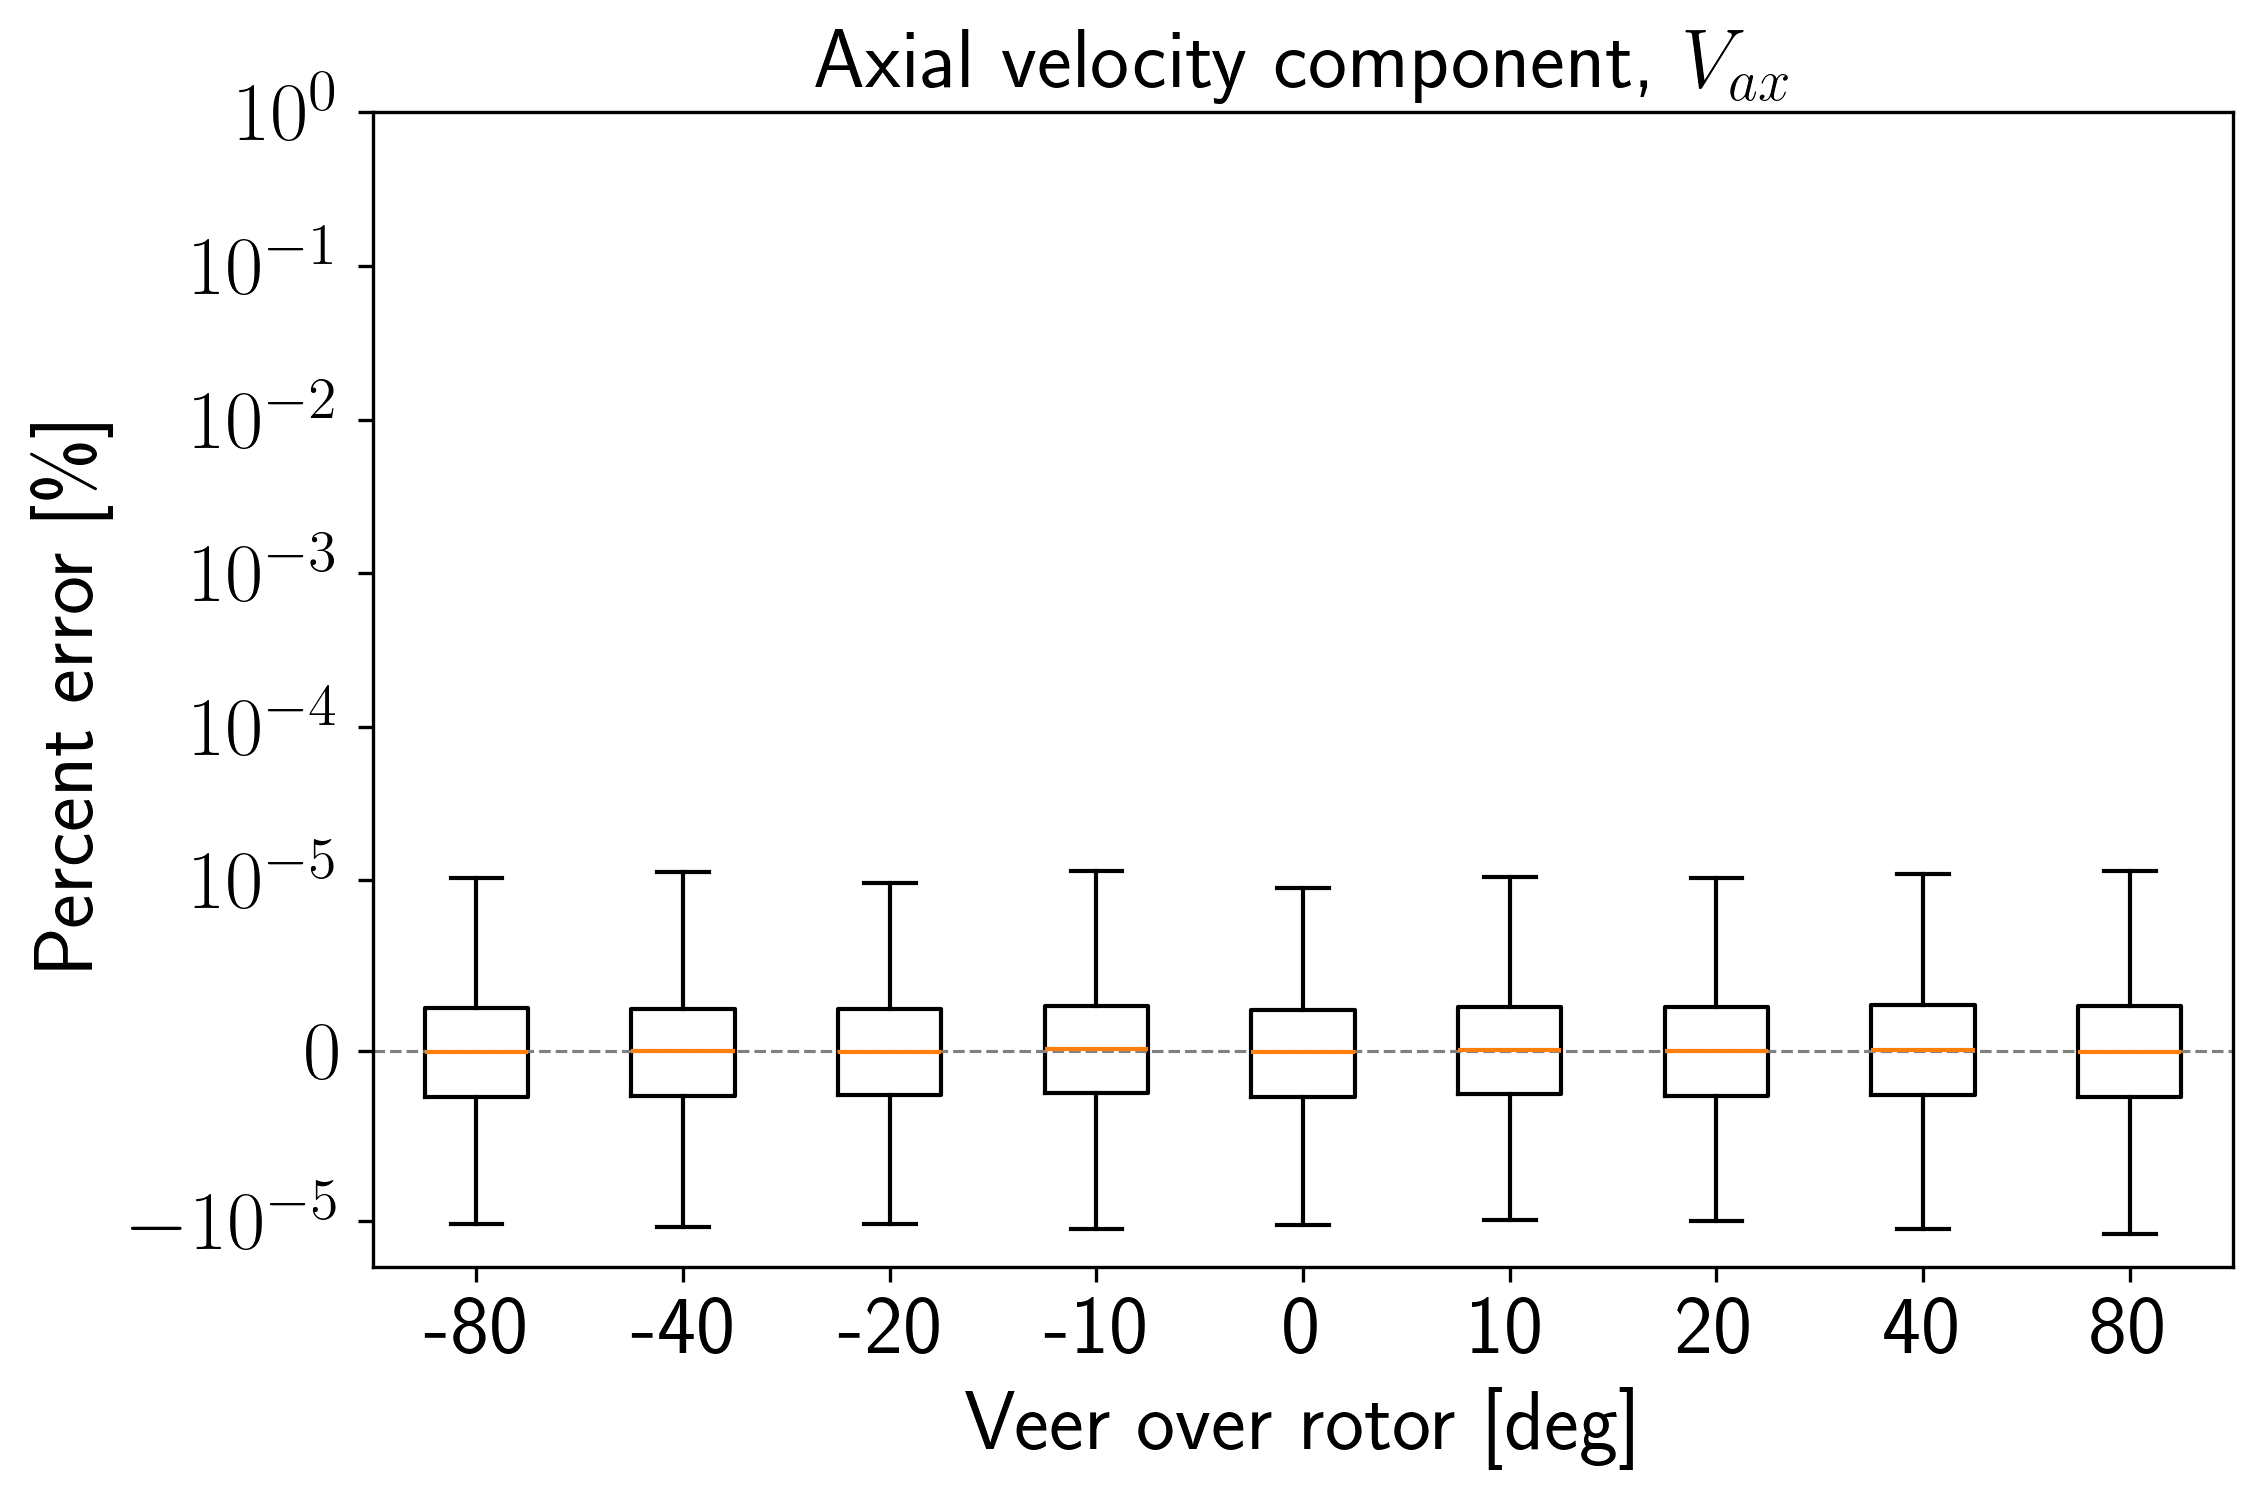

In [55]:
# Axial velocity component

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')


for i in range(len(subset_indices)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(postproc.per_error(wrf_vax[:,:,subset_indices[i]], wrf_vax_real[:,:,subset_indices[i]]), [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Axial velocity component, $V_{ax}$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog',linthresh=1e-5)
ax.set_ylim([-2e-5,1])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

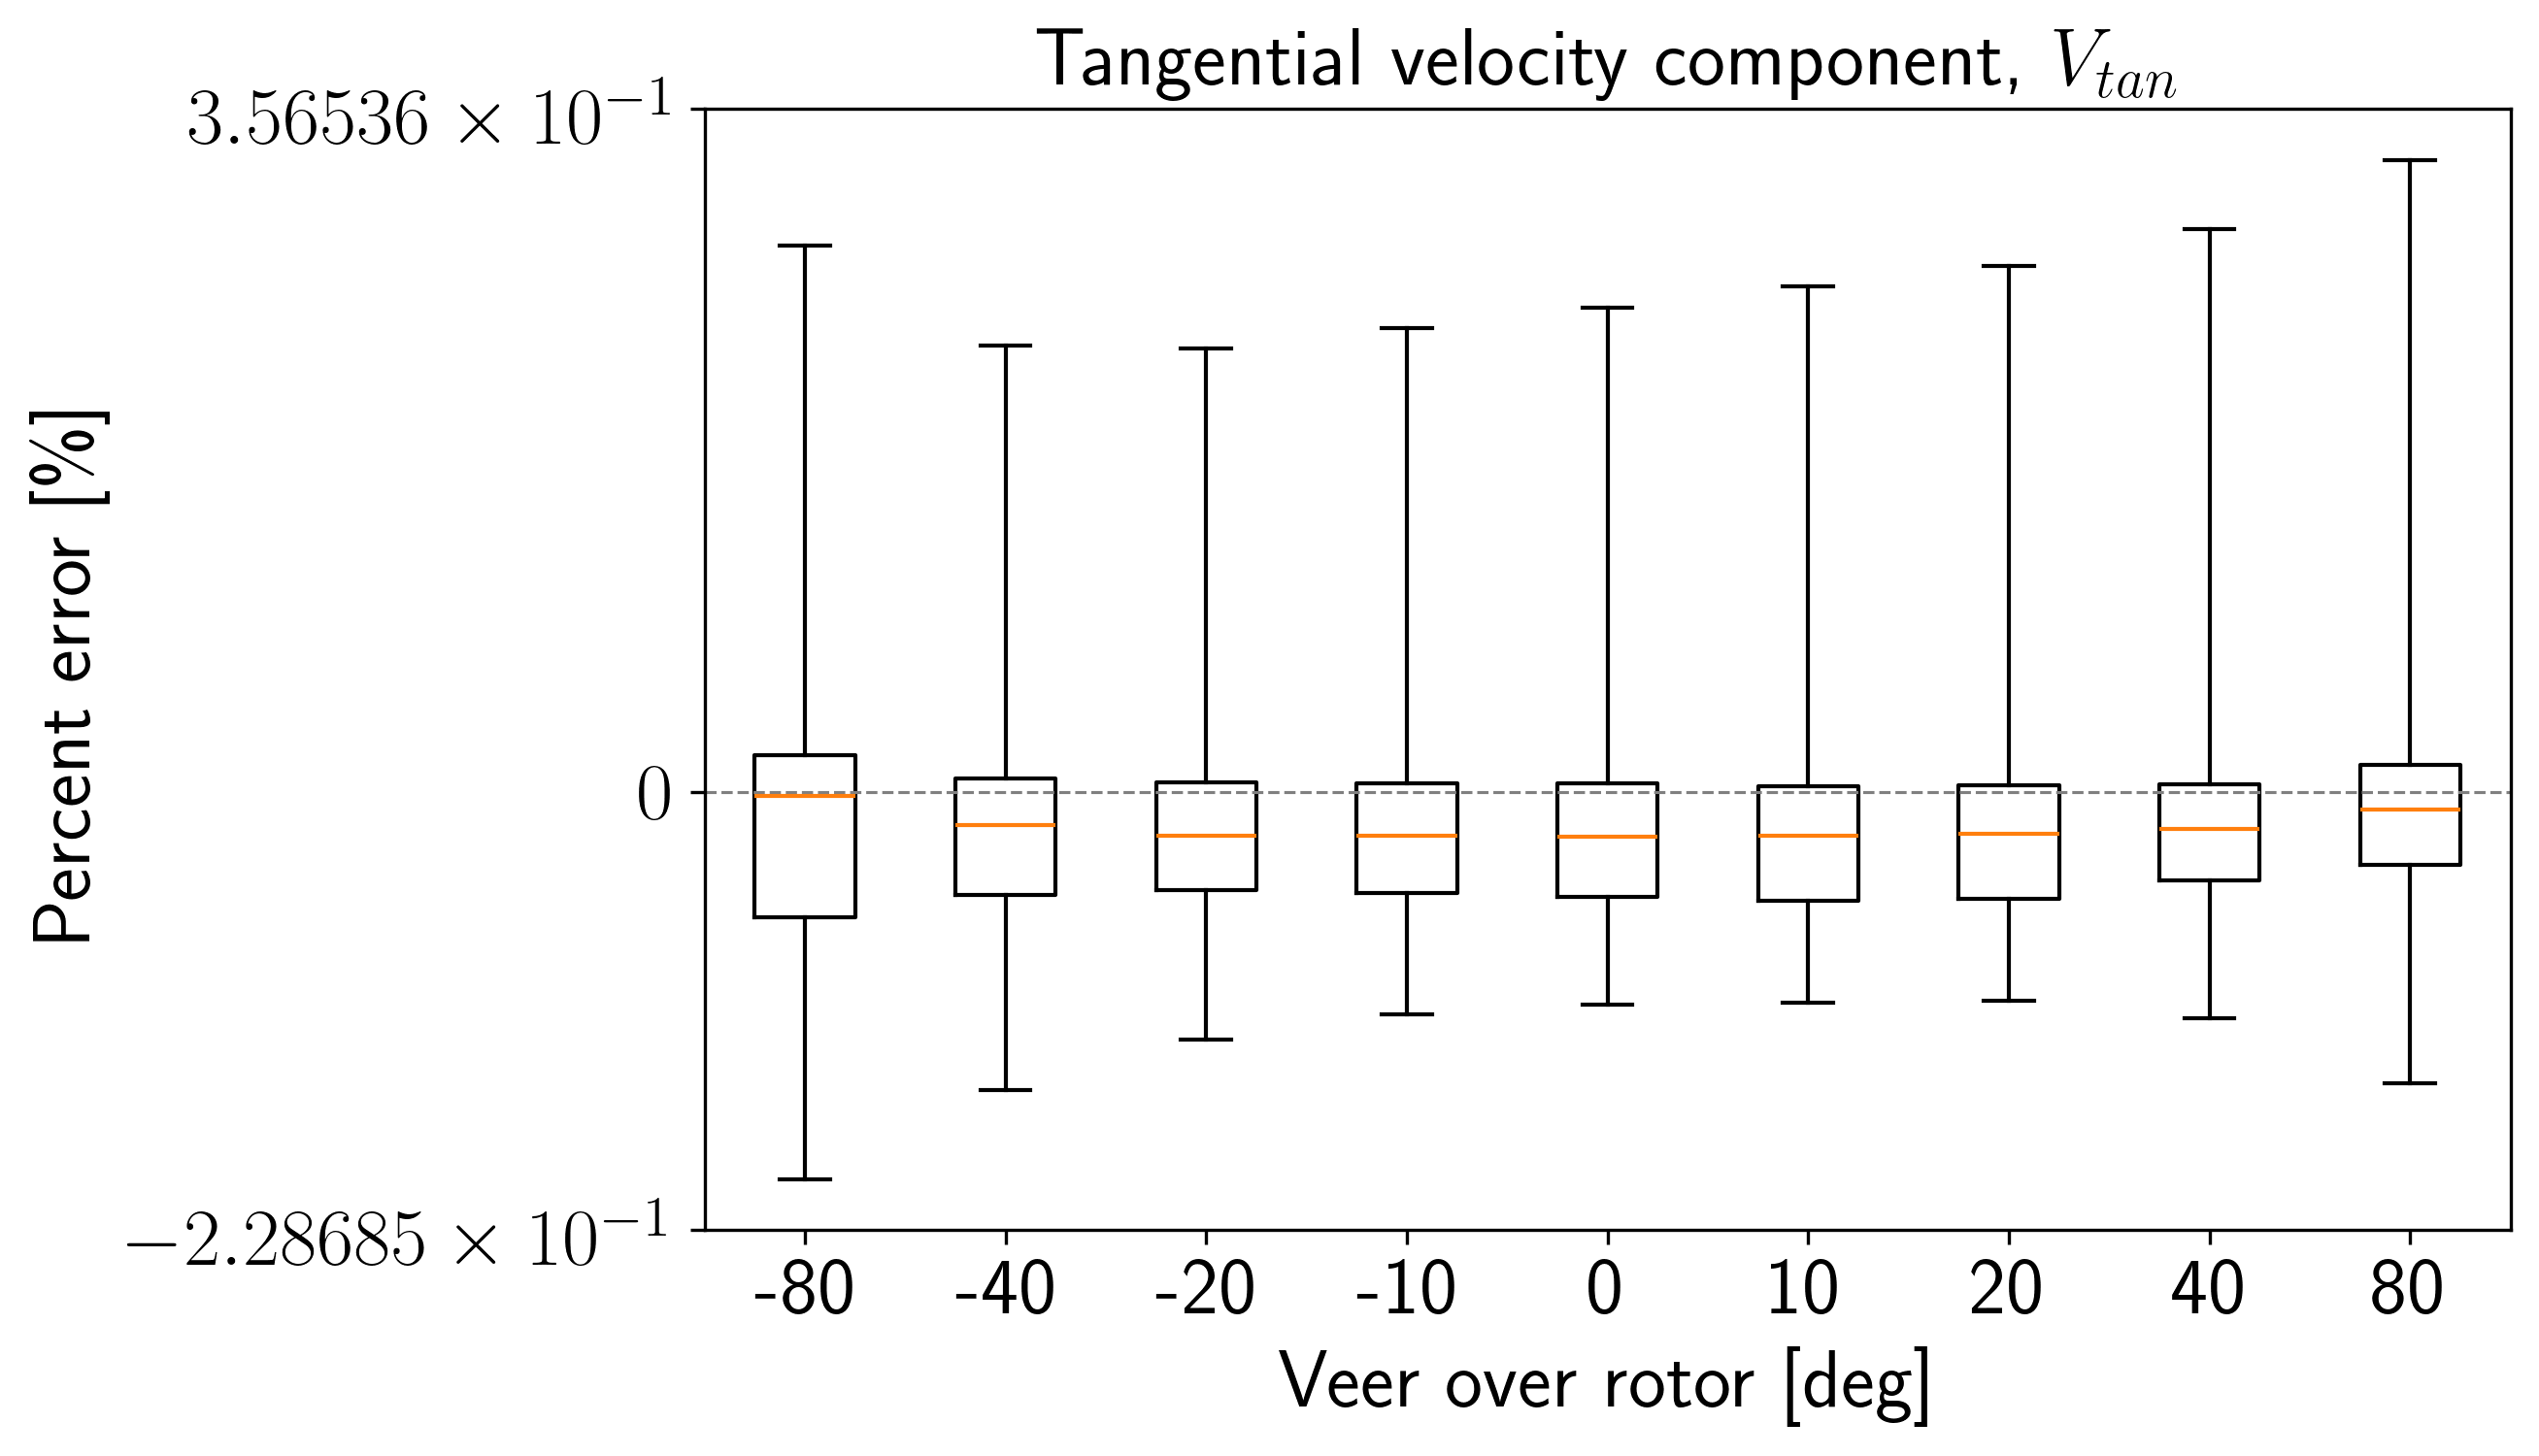

In [64]:
# Tangential velocity component

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')


for i in range(len(subset_indices)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(postproc.per_error(wrf_vtn[:,:,subset_indices[i]], wrf_vtn_real[:,:,subset_indices[i]]), [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Tangential velocity component, $V_{tan}$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
# ax.set_ylim([-10,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

In [34]:
Q3

array([ 3.26075403,  1.89533979,  1.18351385,  0.83107081,  0.50023987,
        0.21135829, -0.04855148, -0.60160902, -1.80162629])

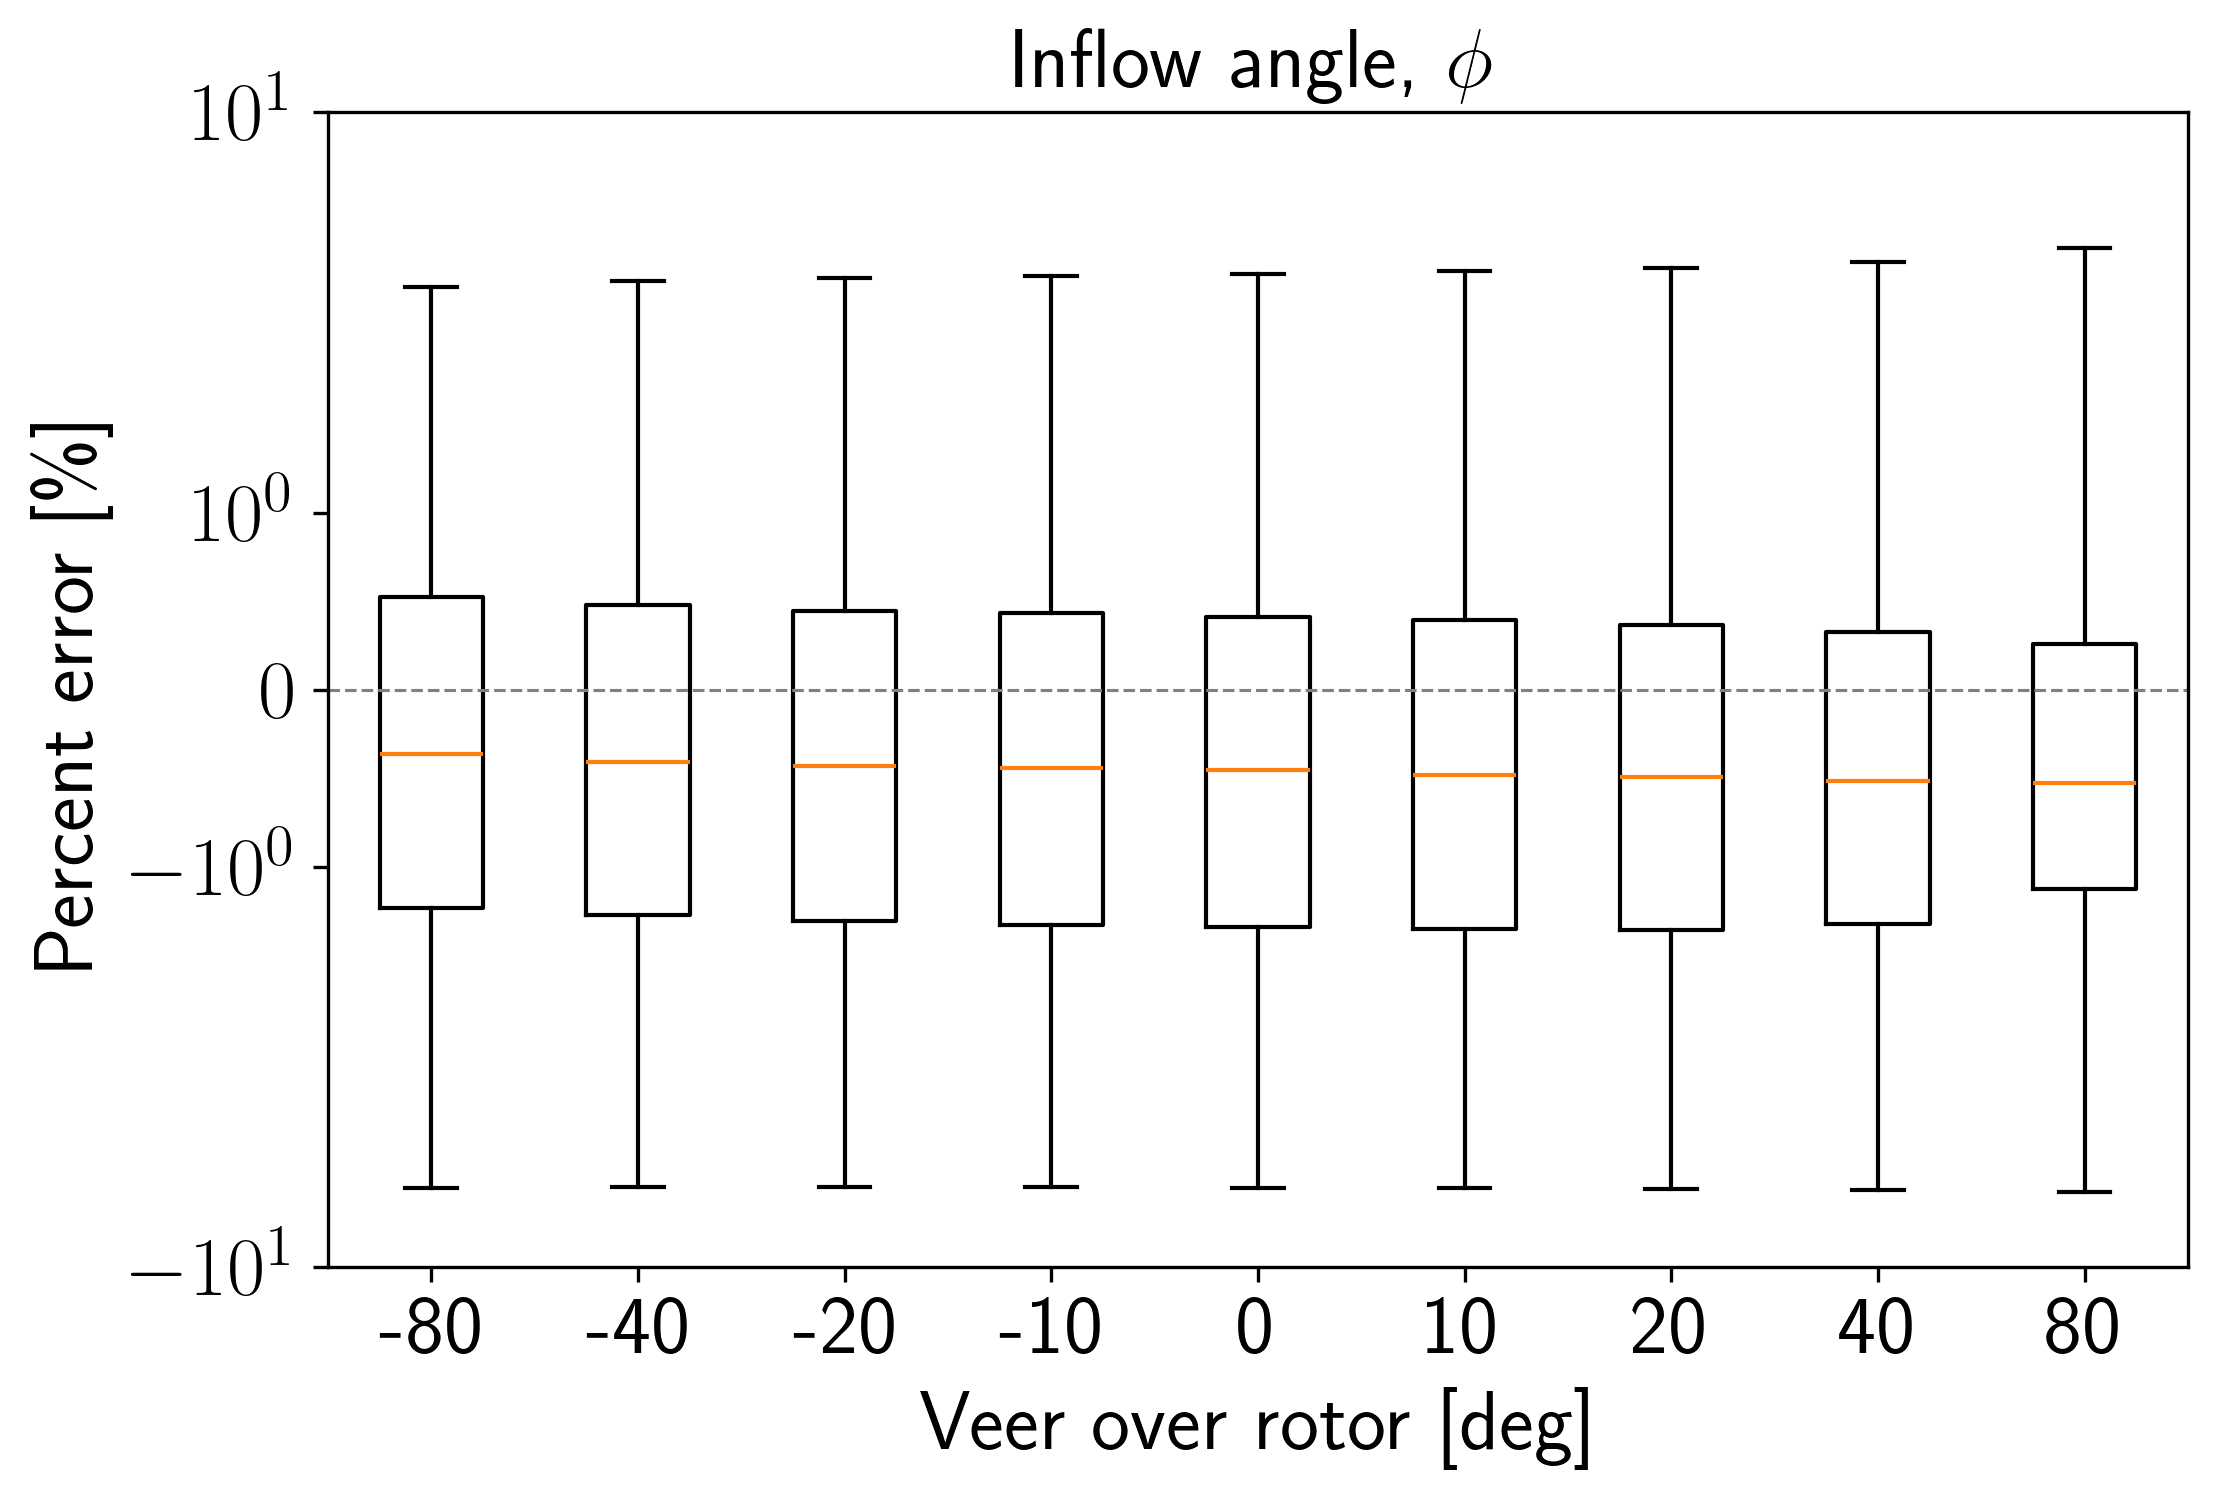

In [16]:
# Inflow angle

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')


for i in range(len(subset_indices)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(postproc.per_error(wrf_phi[:,:,subset_indices[i]], wrf_phi_real[:,:,subset_indices[i]]), [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Inflow angle, $\phi$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
ax.set_ylim([-10,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

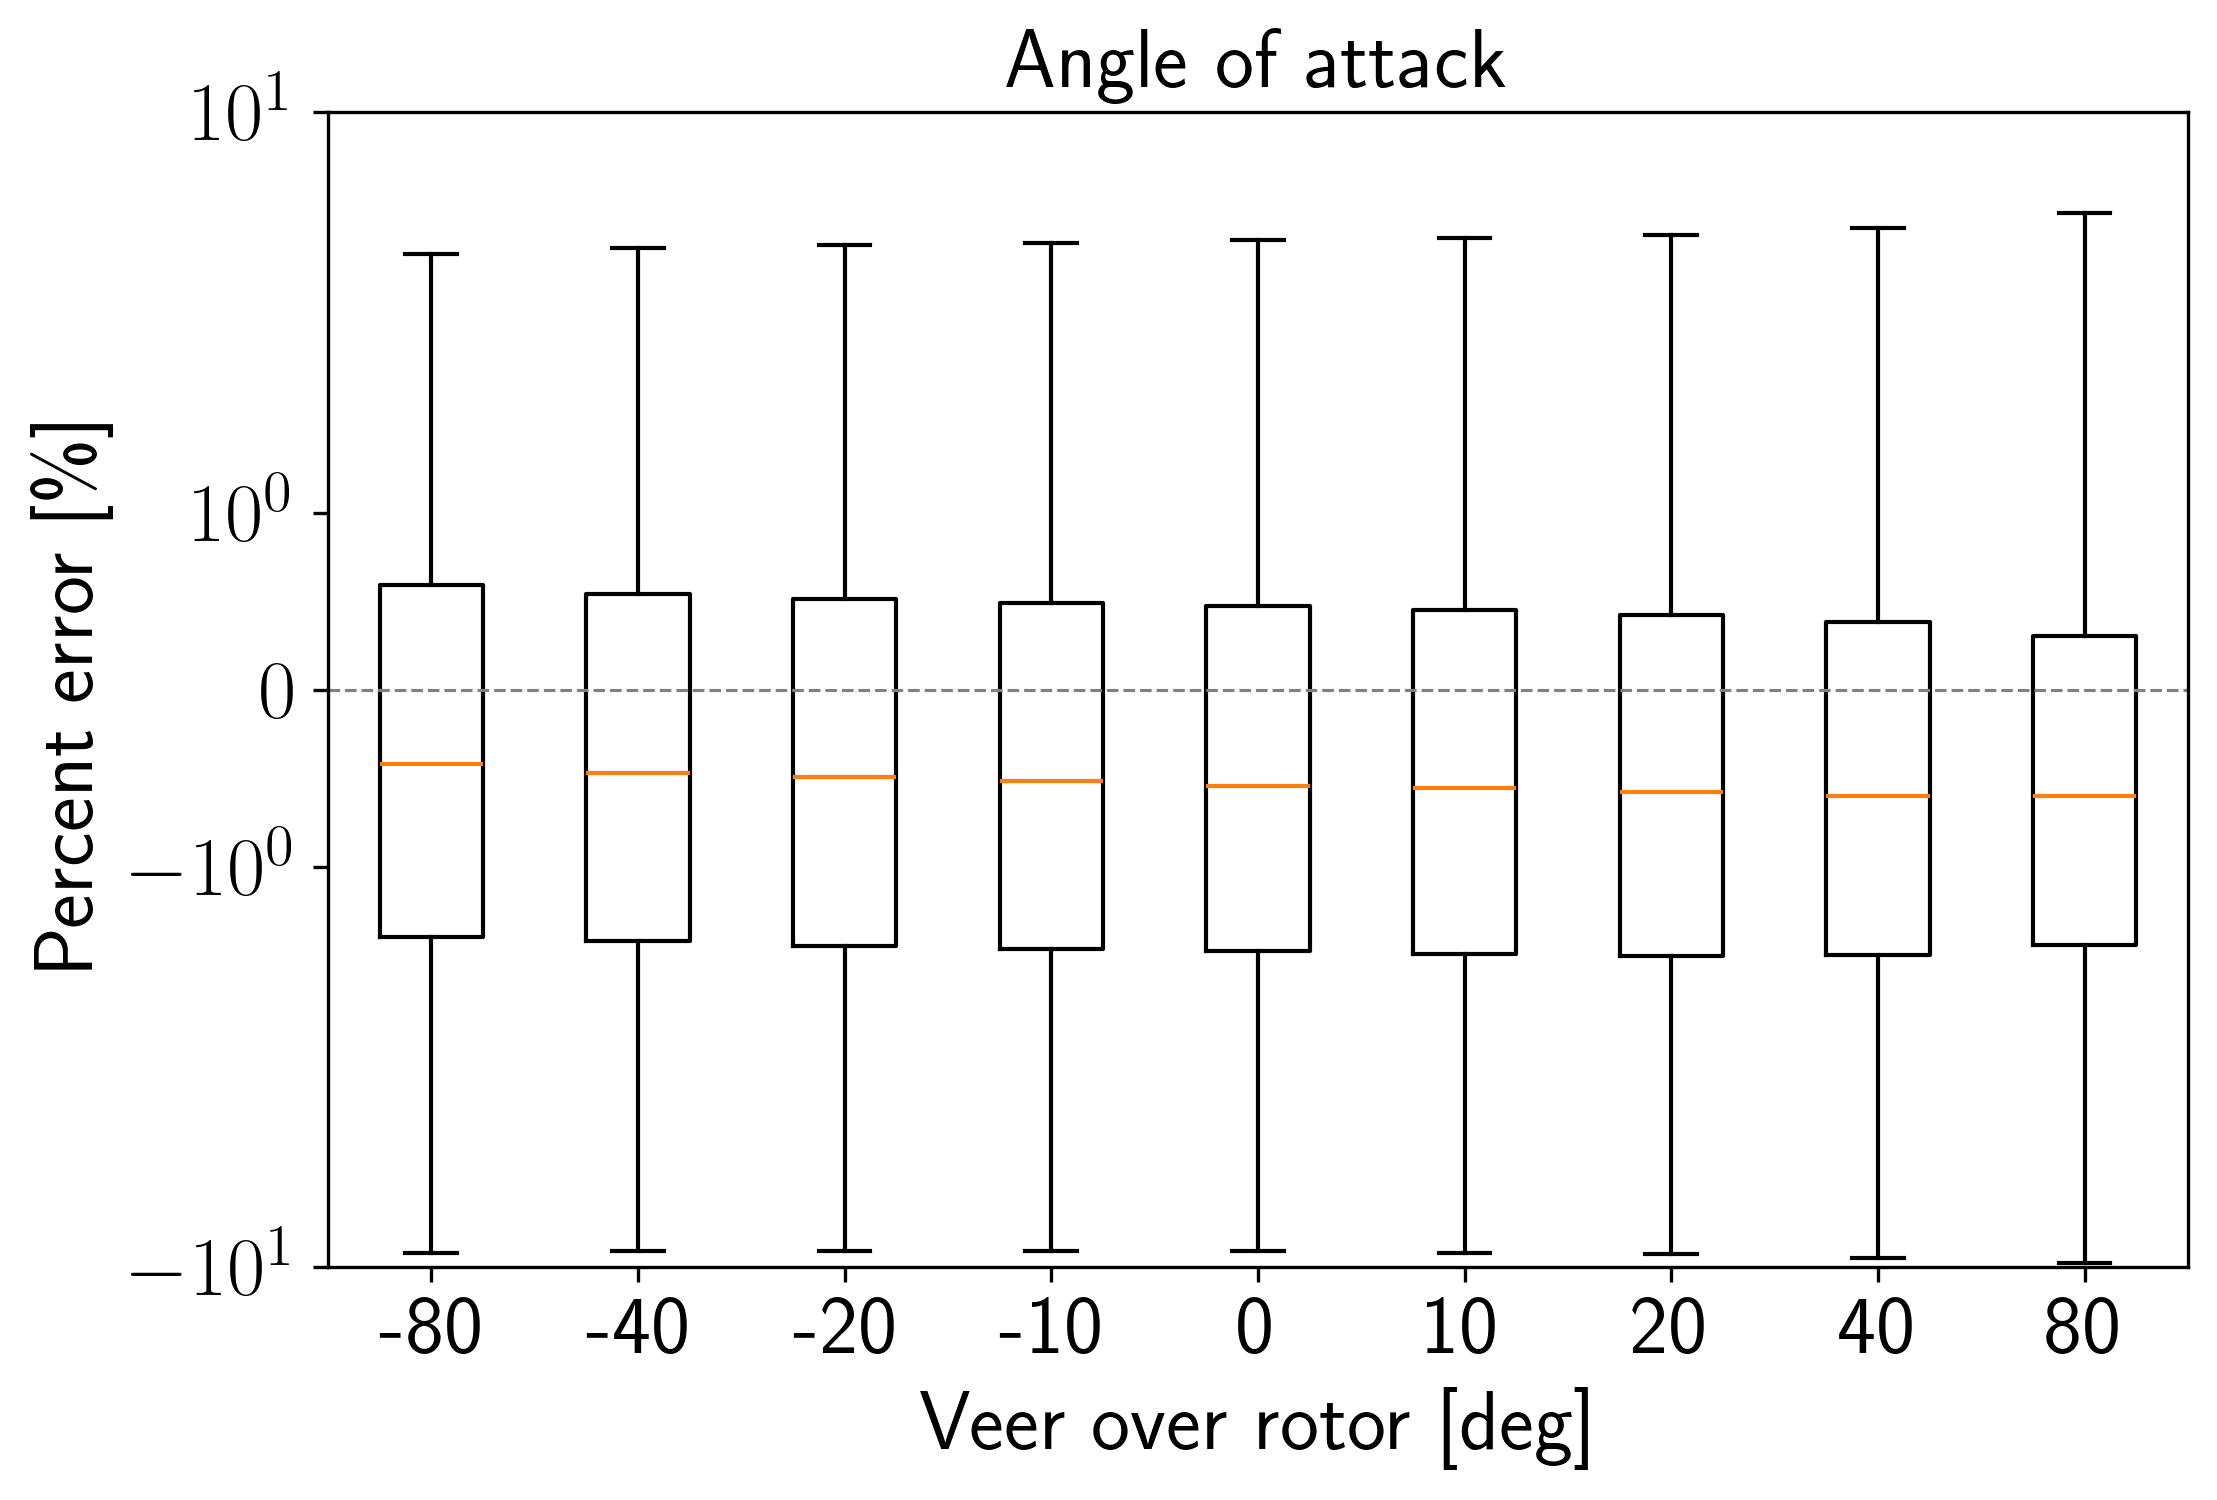

In [17]:
# Angle of attack

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')


for i in range(len(subset_indices)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(postproc.per_error(wrf_aoa[:,:,subset_indices[i]], wrf_aoa_real[:,:,subset_indices[i]]), [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Angle of attack",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
ax.set_ylim([-10,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

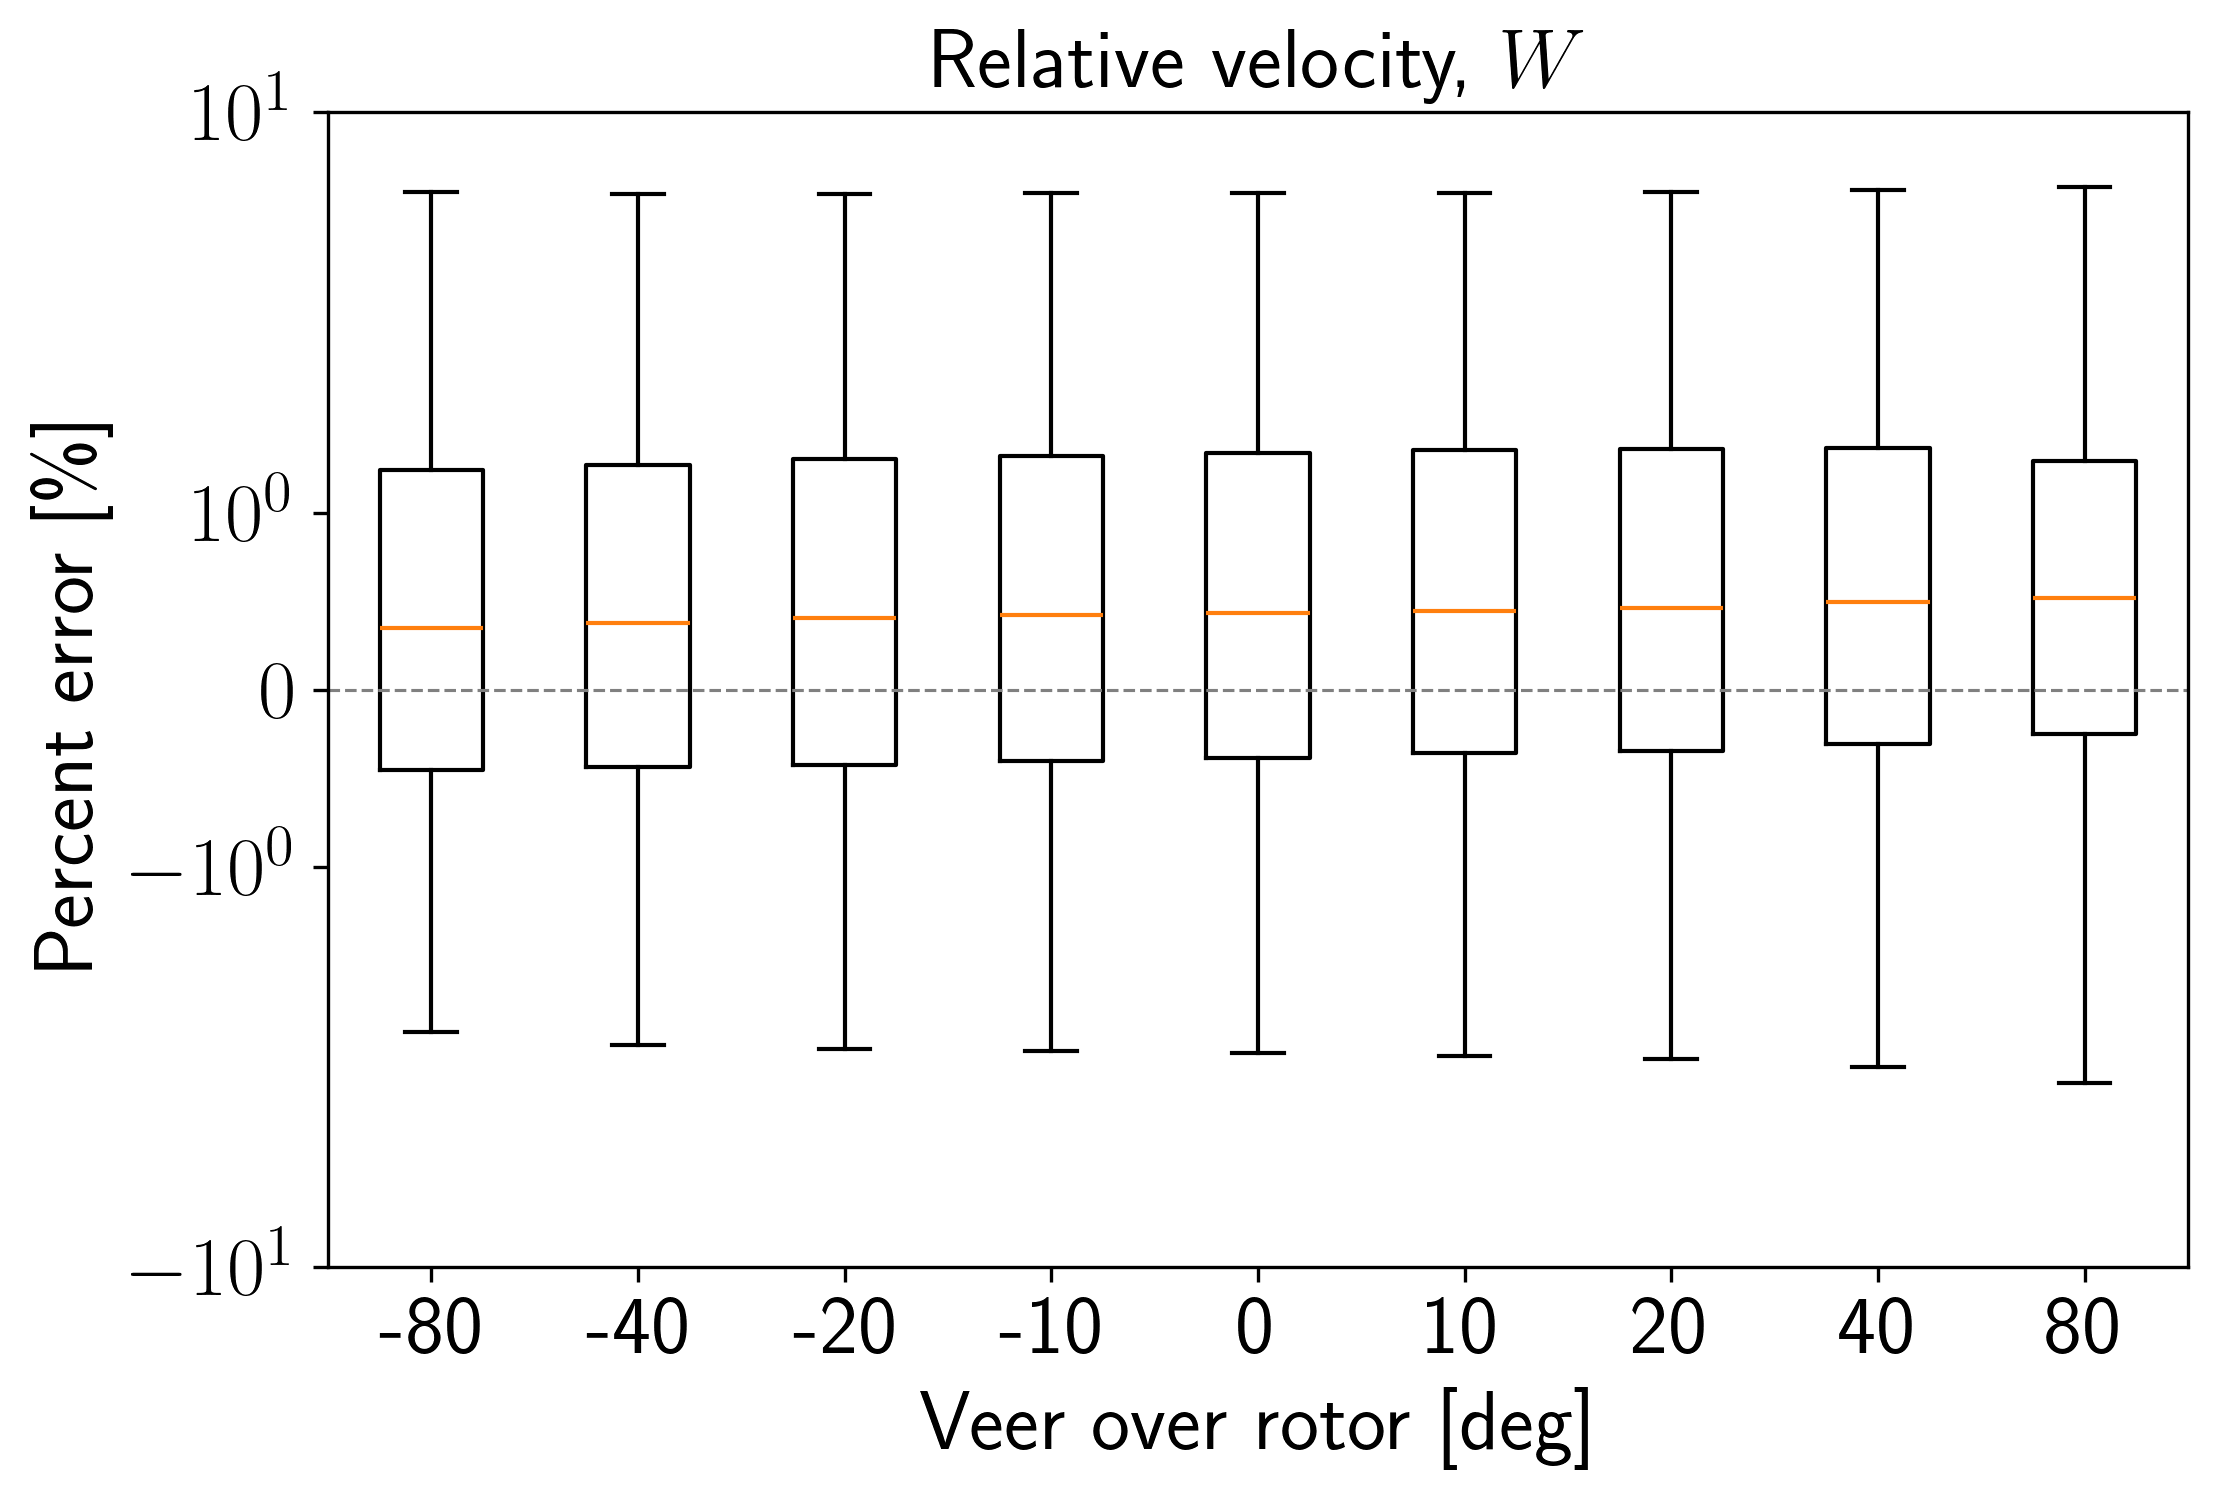

In [18]:
# Relative velocity

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')


for i in range(len(subset_indices)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(postproc.per_error(wrf_W[:,:,subset_indices[i]], wrf_W_real[:,:,subset_indices[i]]), [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Relative velocity, $W$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
ax.set_ylim([-10,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

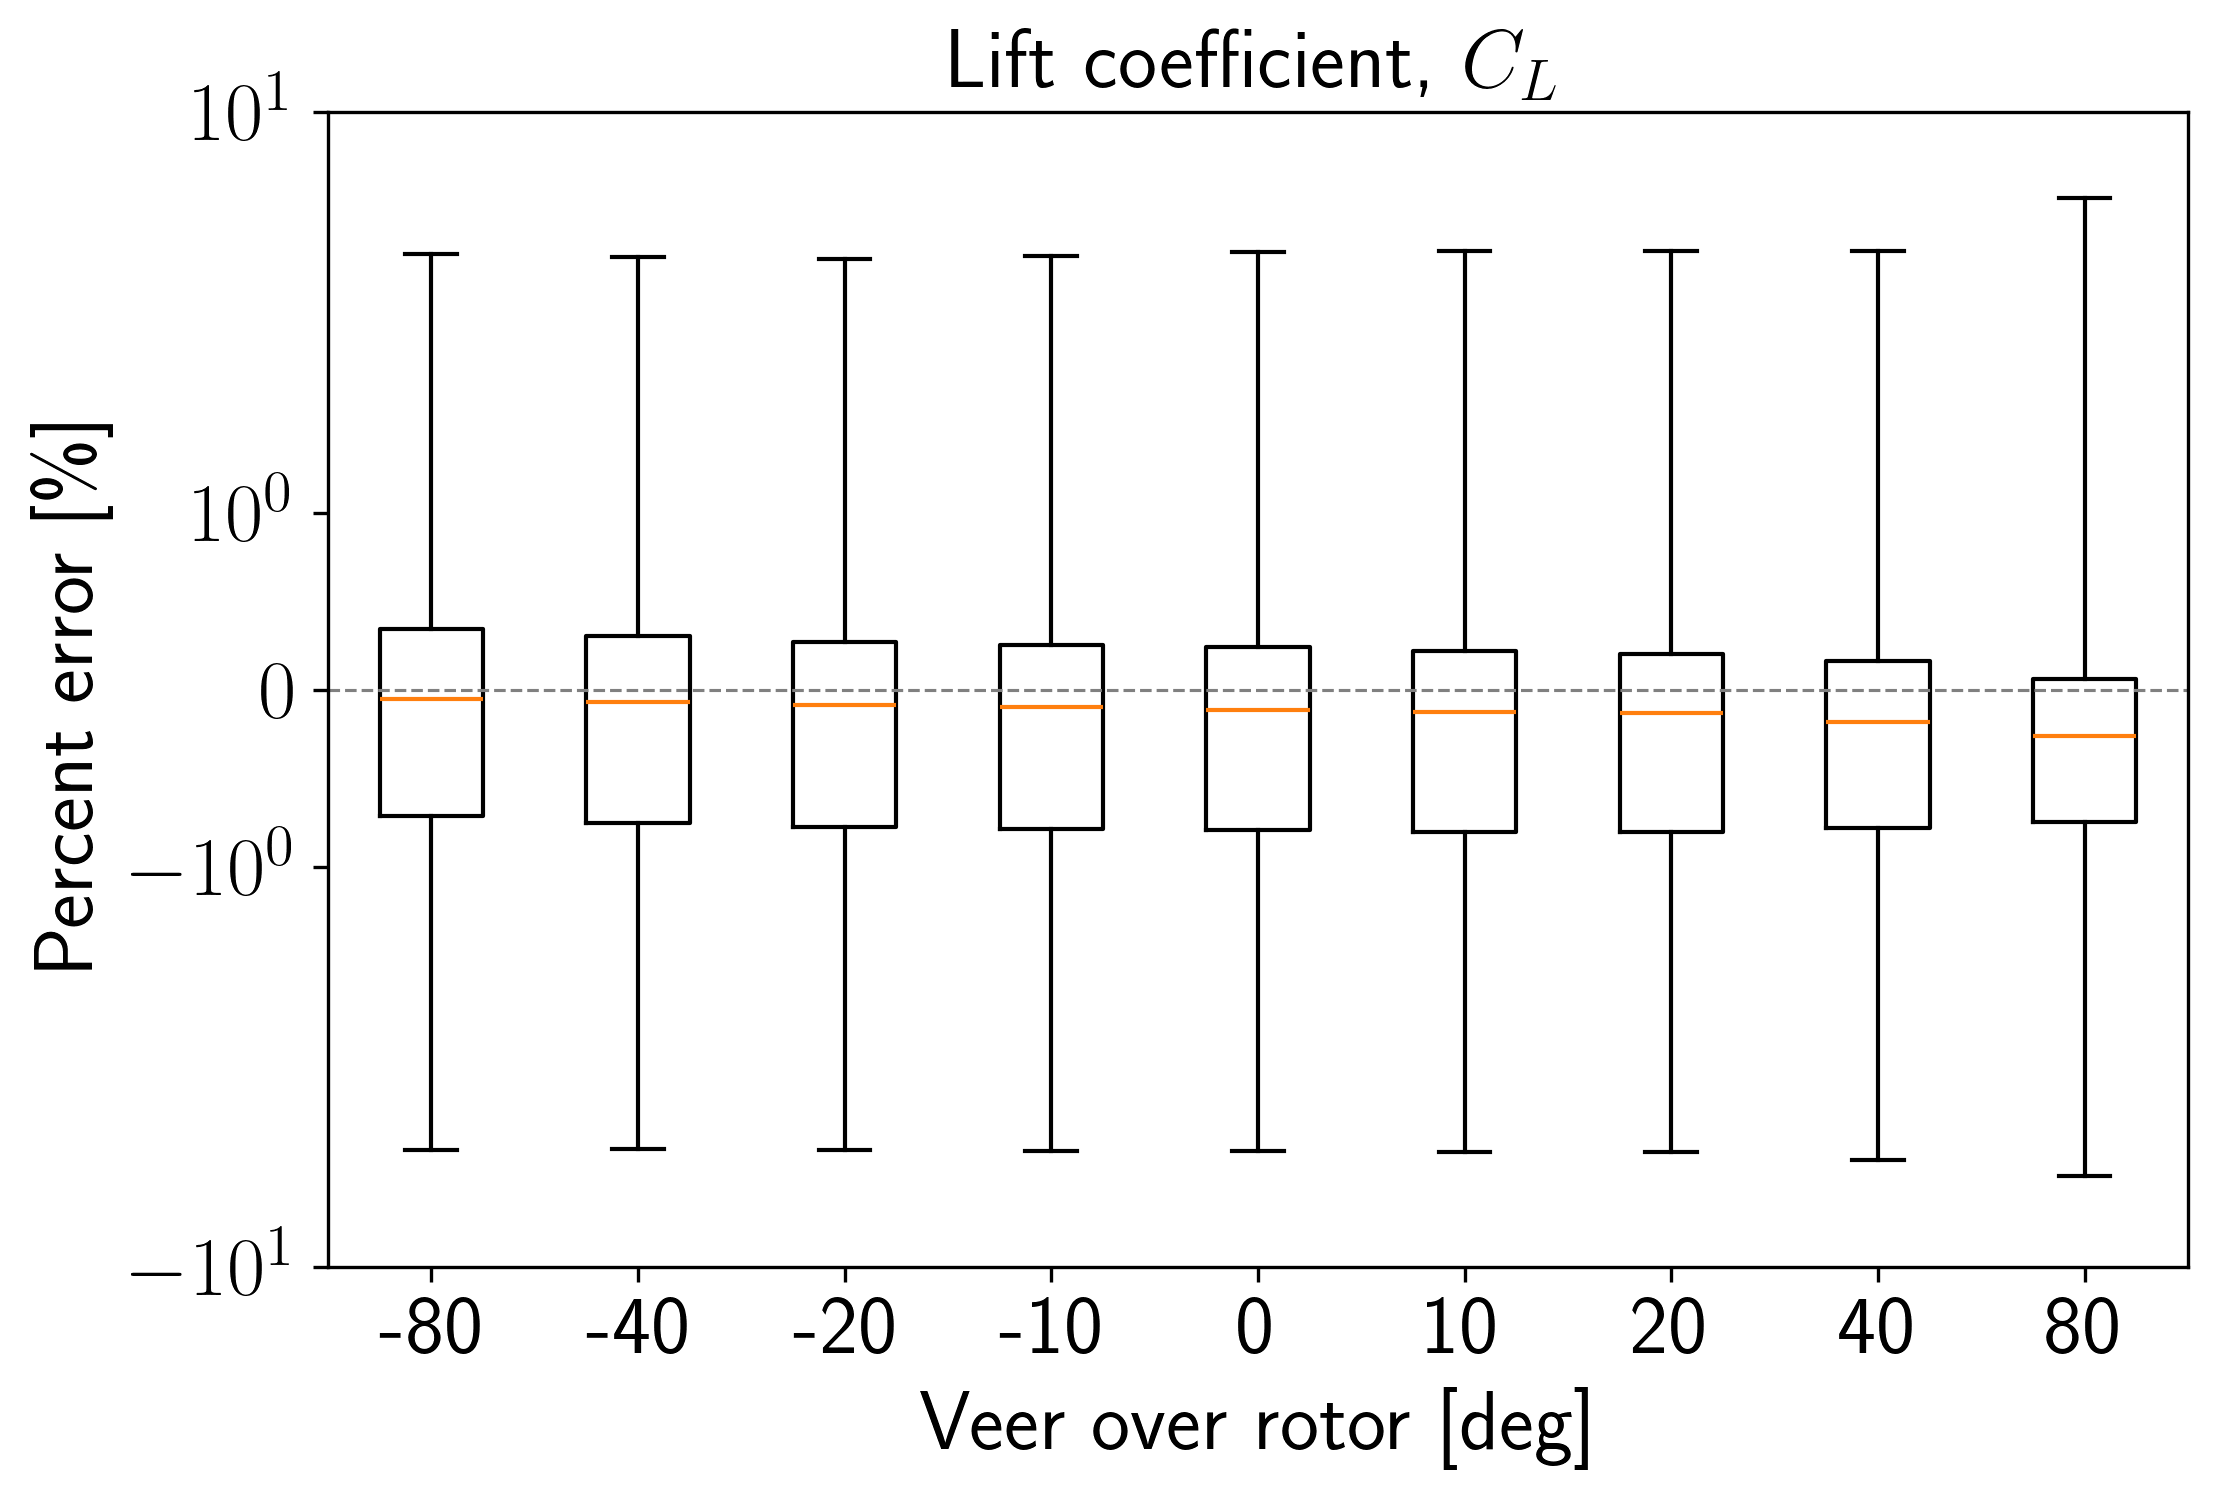

In [19]:
# Lift coefficient

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')

for i in range(len(subset_indices)):
    CLerrors = postproc.per_error(wrf_CL[:,:,subset_indices[i]], wrf_CL_real[:,:,subset_indices[i]])
    CLerrors[np.isinf(CLerrors)] = 0
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(CLerrors, [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Lift coefficient, $C_L$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
ax.set_ylim([-10,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

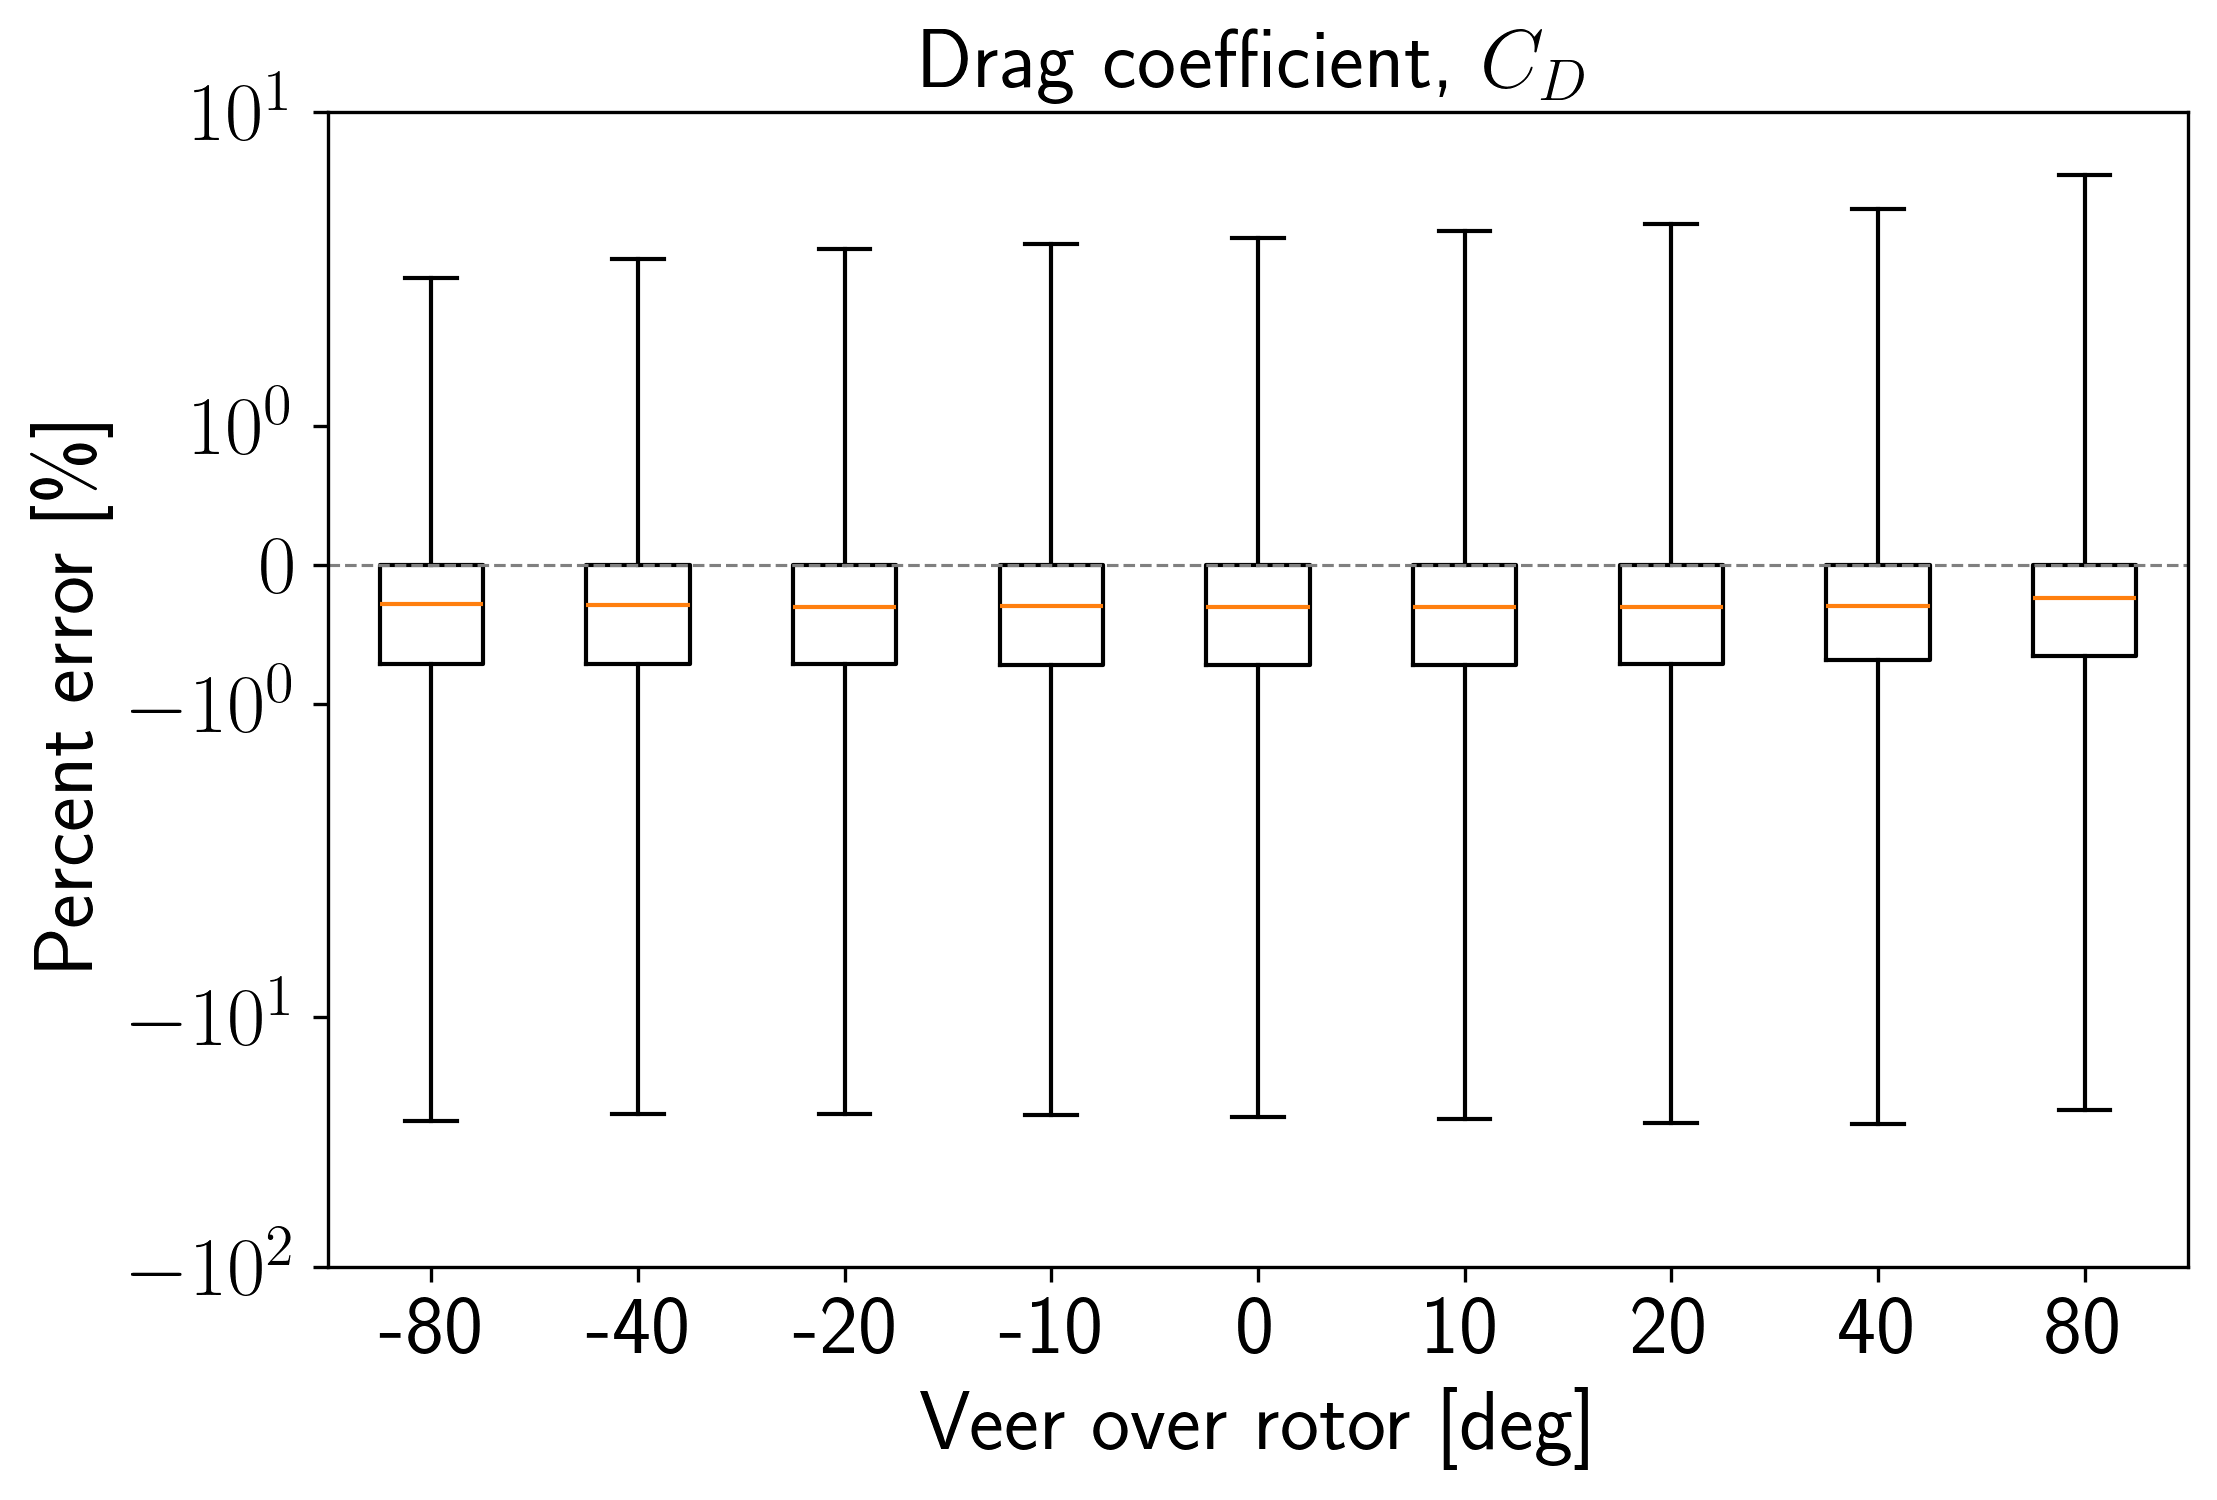

In [20]:
# Drag coefficient

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')


for i in range(len(subset_indices)):
    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(postproc.per_error(wrf_CD[:,:,subset_indices[i]], wrf_CD_real[:,:,subset_indices[i]]), [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Drag coefficient, $C_D$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
ax.set_ylim([-100,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

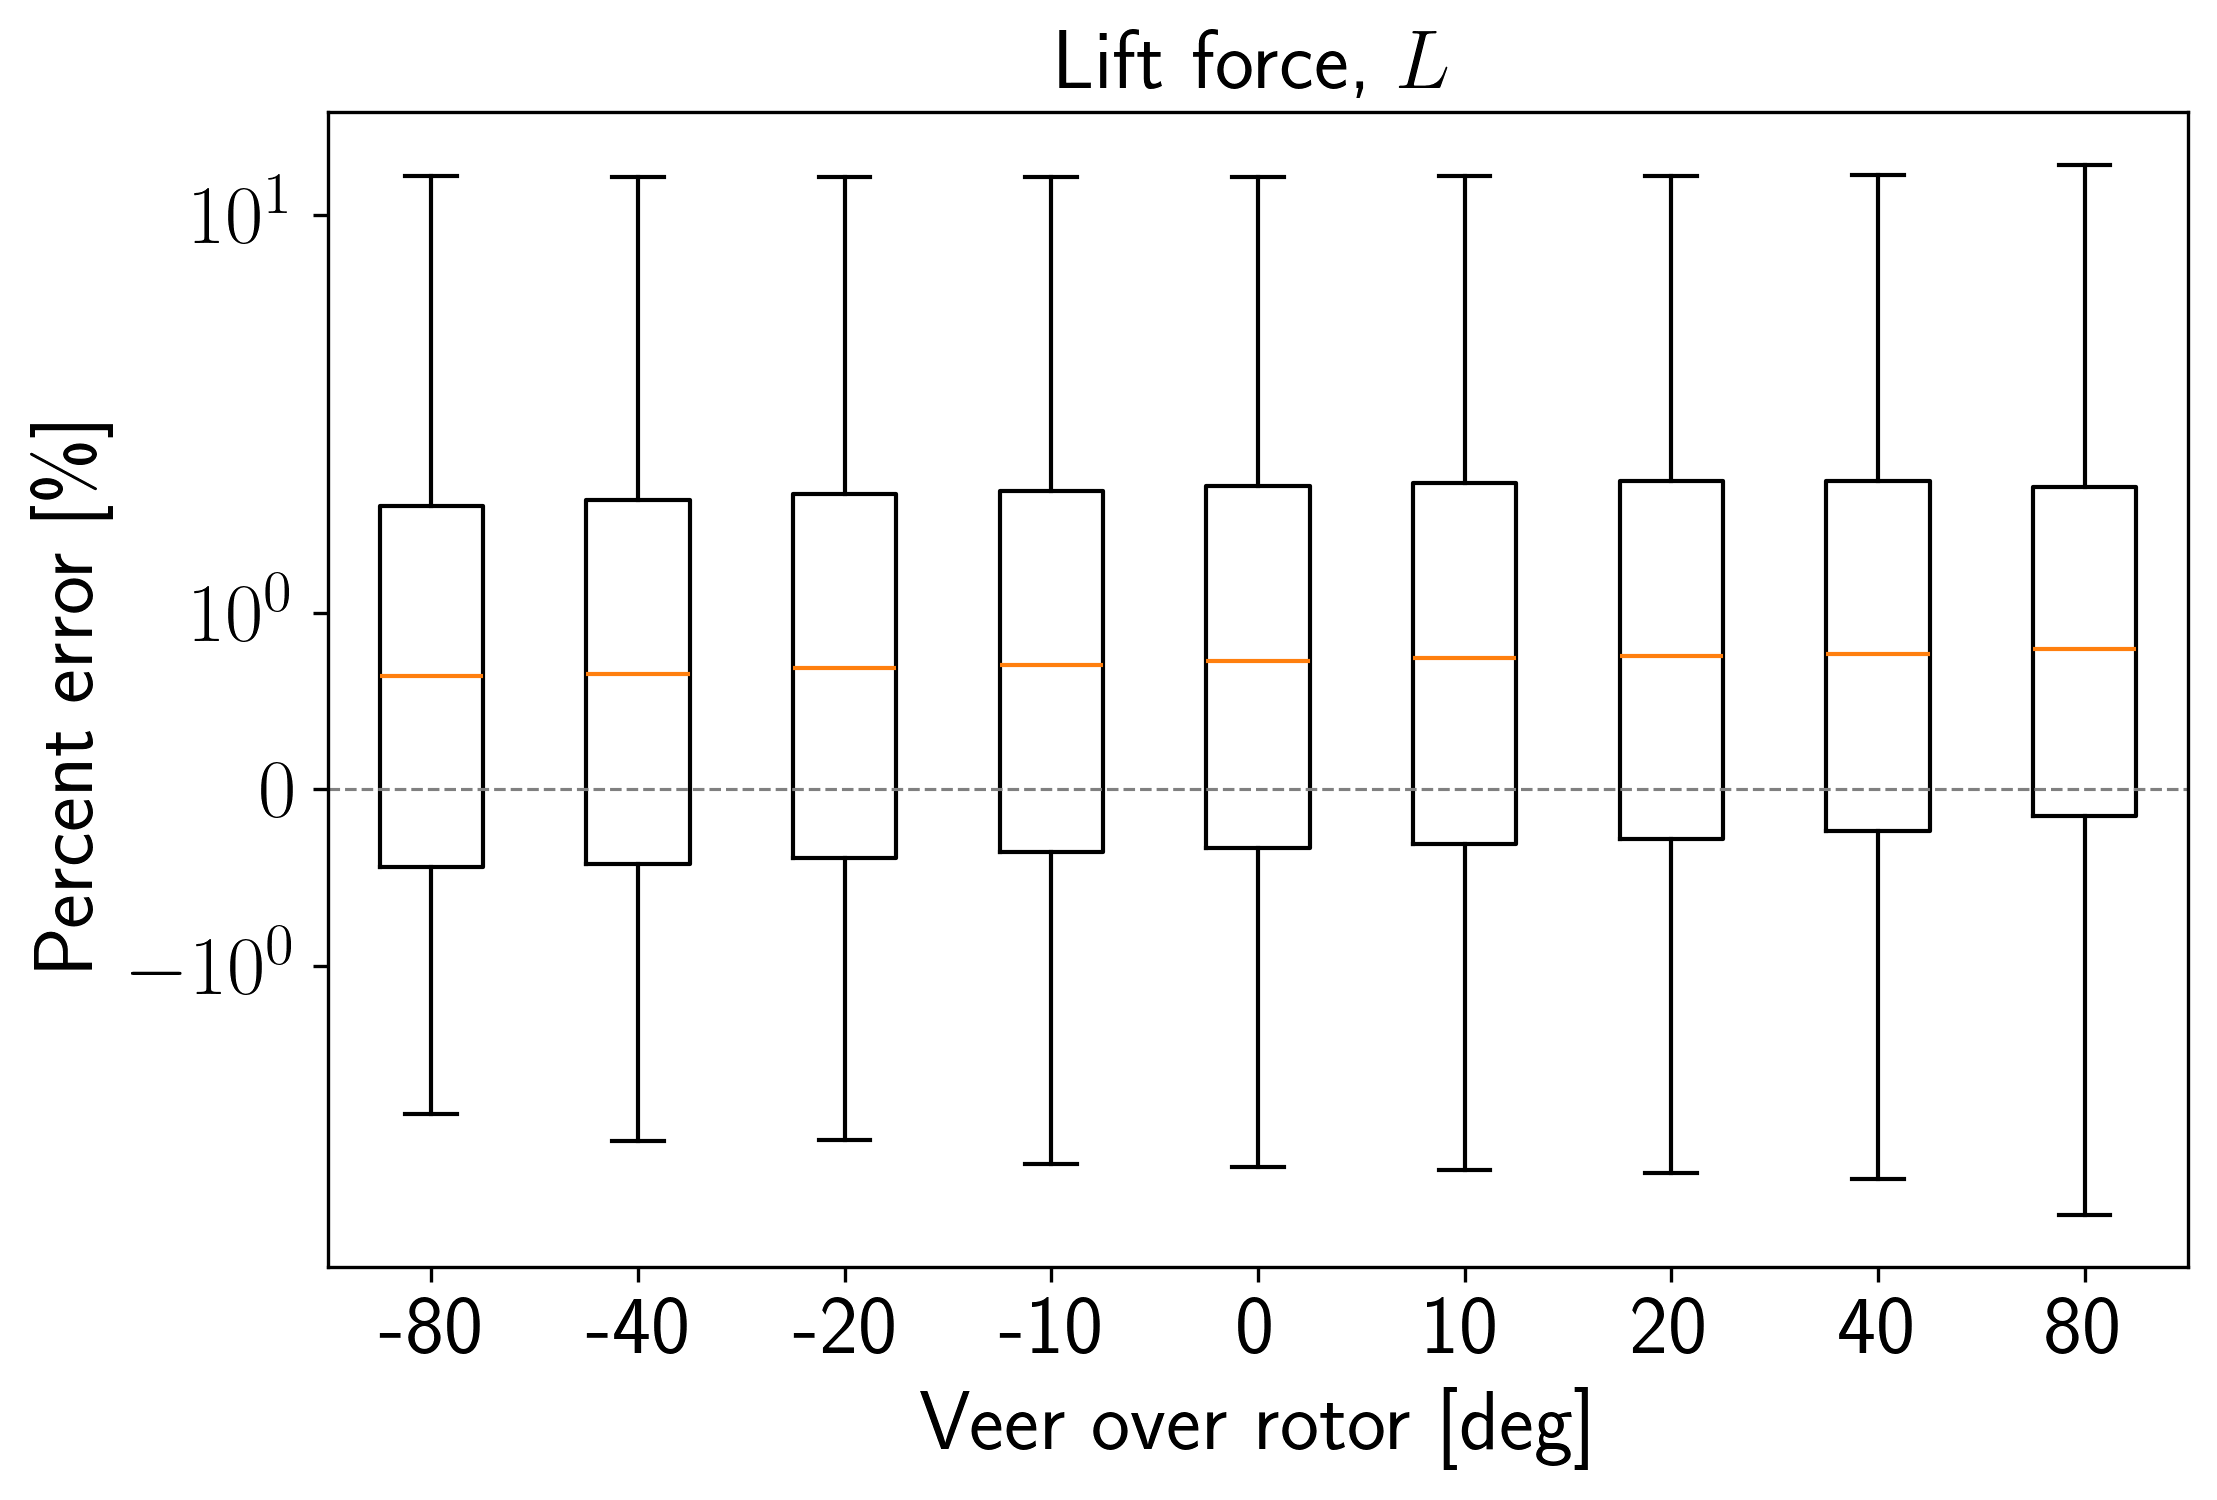

In [21]:
# Lift force

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')

wrf_L = 1/2 * rho * chord[:, :, np.newaxis] * (wrf_CL * (wrf_W * Uhub)**2)

for i in range(len(subset_indices)):

    errors = postproc.per_error(wrf_L[:,:,subset_indices[i]], wrf_L_real[:,:,subset_indices[i]])

    errors = errors[np.isfinite(errors)]

    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(errors, [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Lift force, $L$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
# ax.set_ylim([-100,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

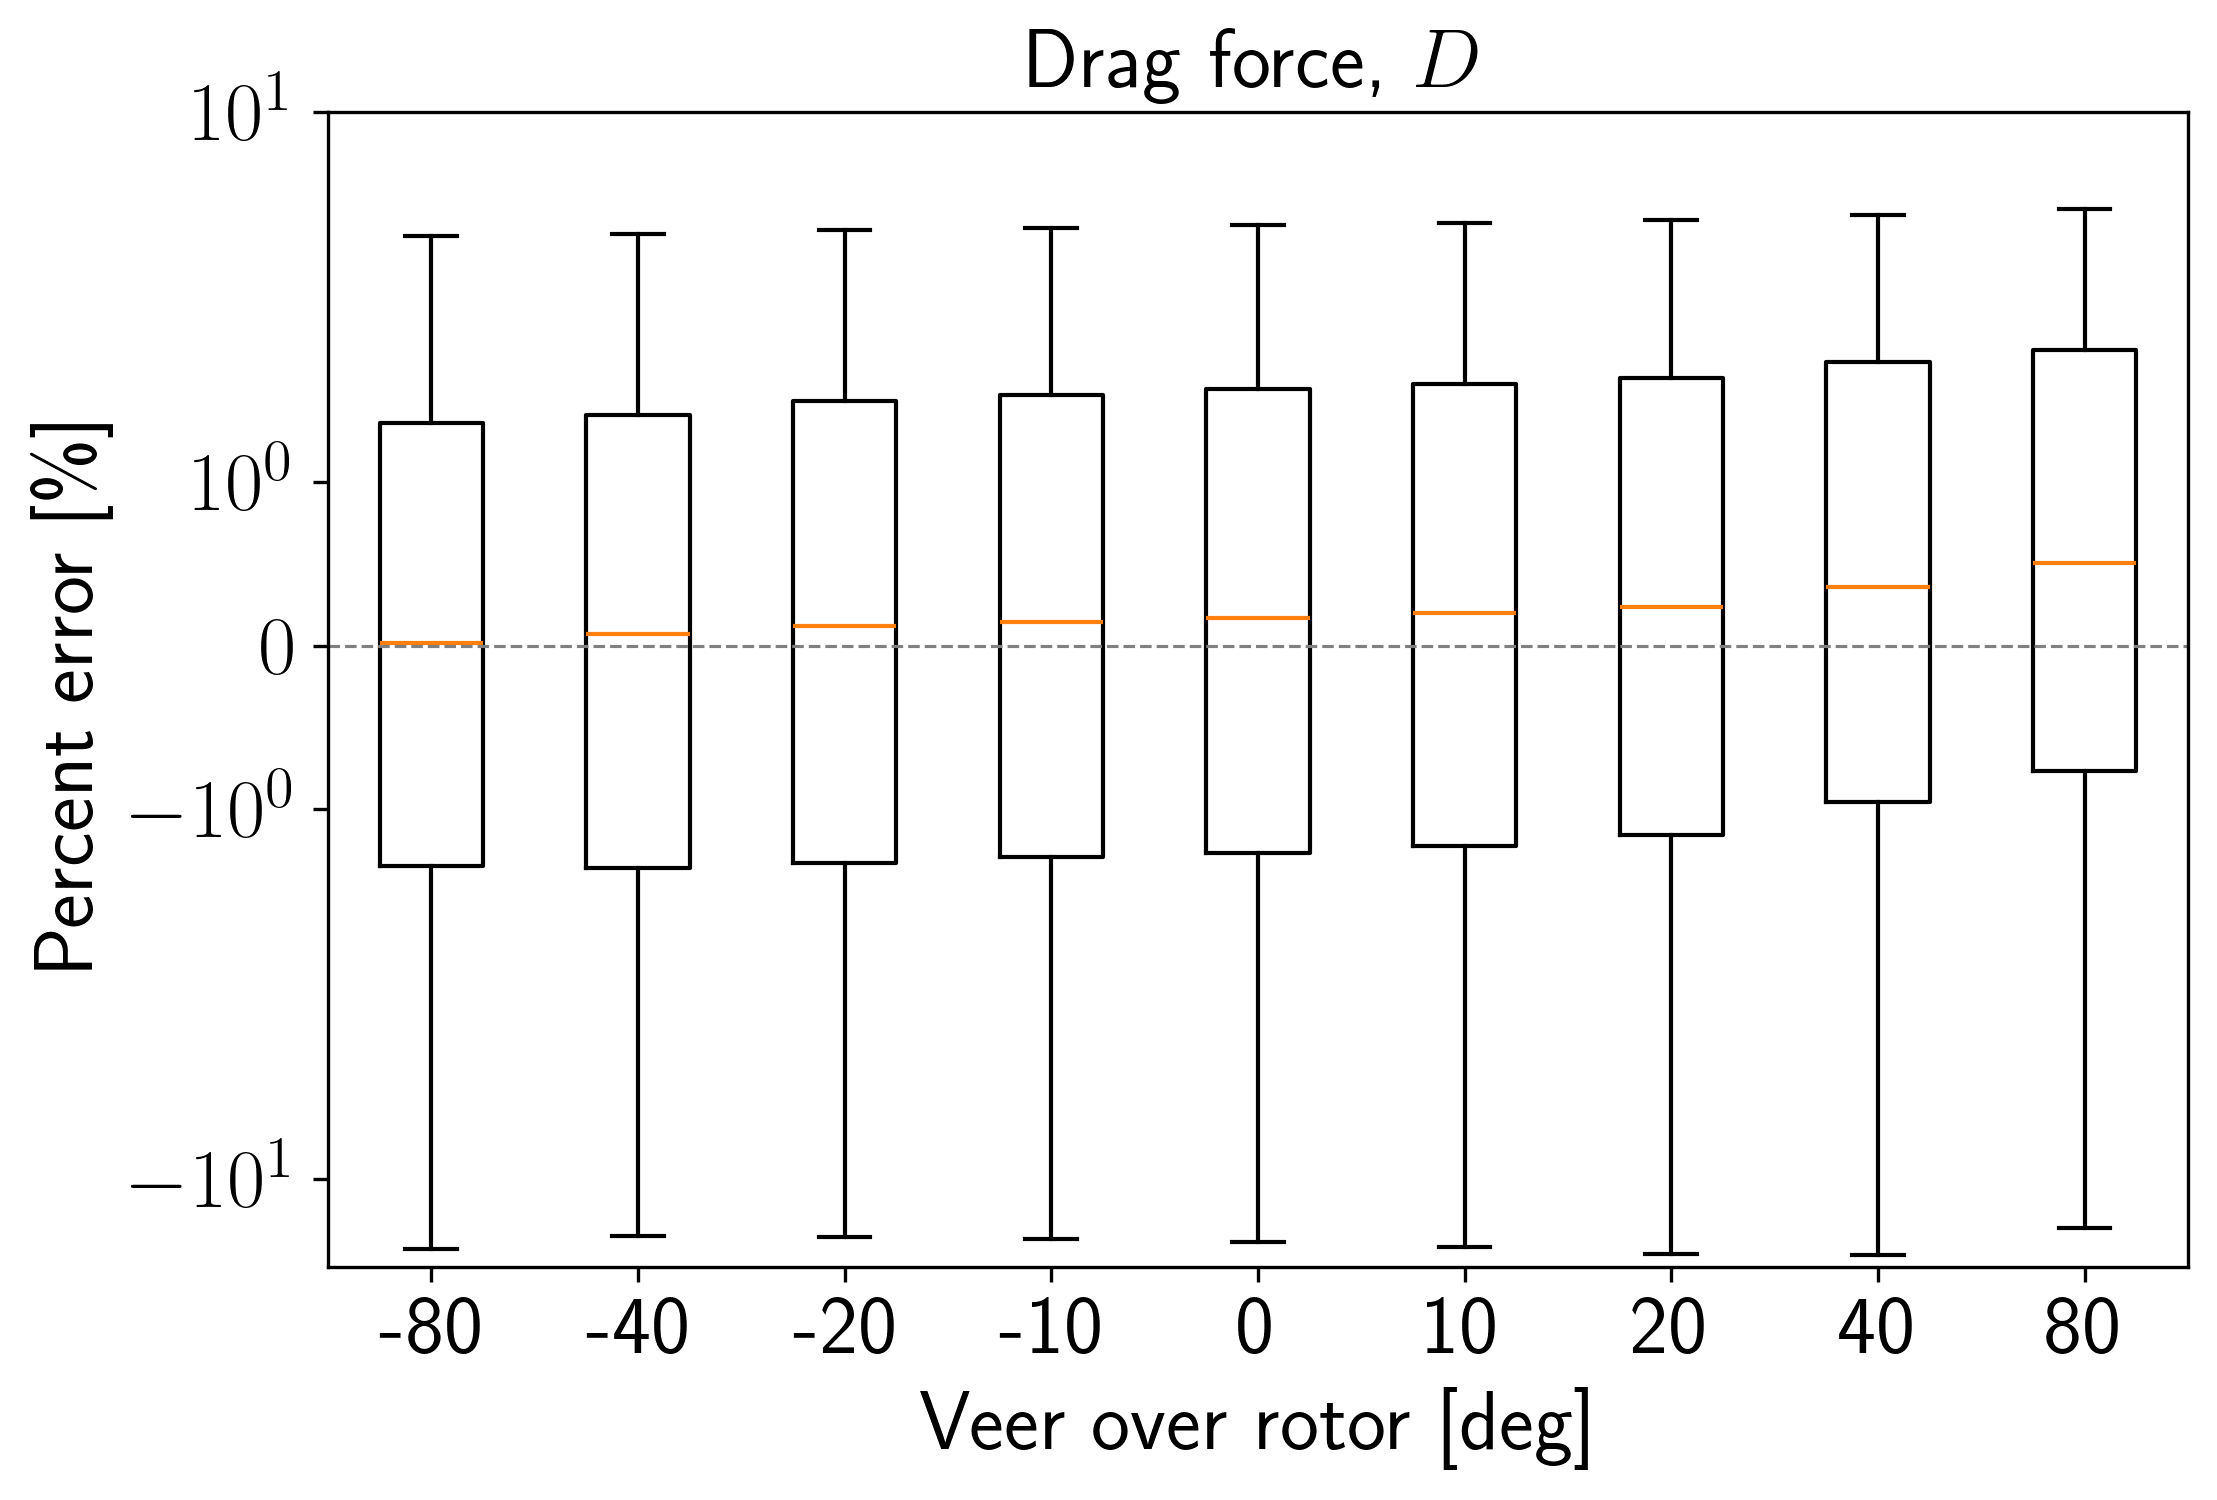

In [22]:
# Drag force

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')

wrf_D = 1/2 * rho * chord[:, :, np.newaxis] * (wrf_CD * (wrf_W * Uhub)**2)

for i in range(len(subset_indices)):
    errors = postproc.per_error(wrf_D[:,:,subset_indices[i]], wrf_D_real[:,:,subset_indices[i]])

    errors = errors[np.isfinite(errors)]

    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(errors, [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Drag force, $D$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog')
ax.set_ylim([-20,10])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

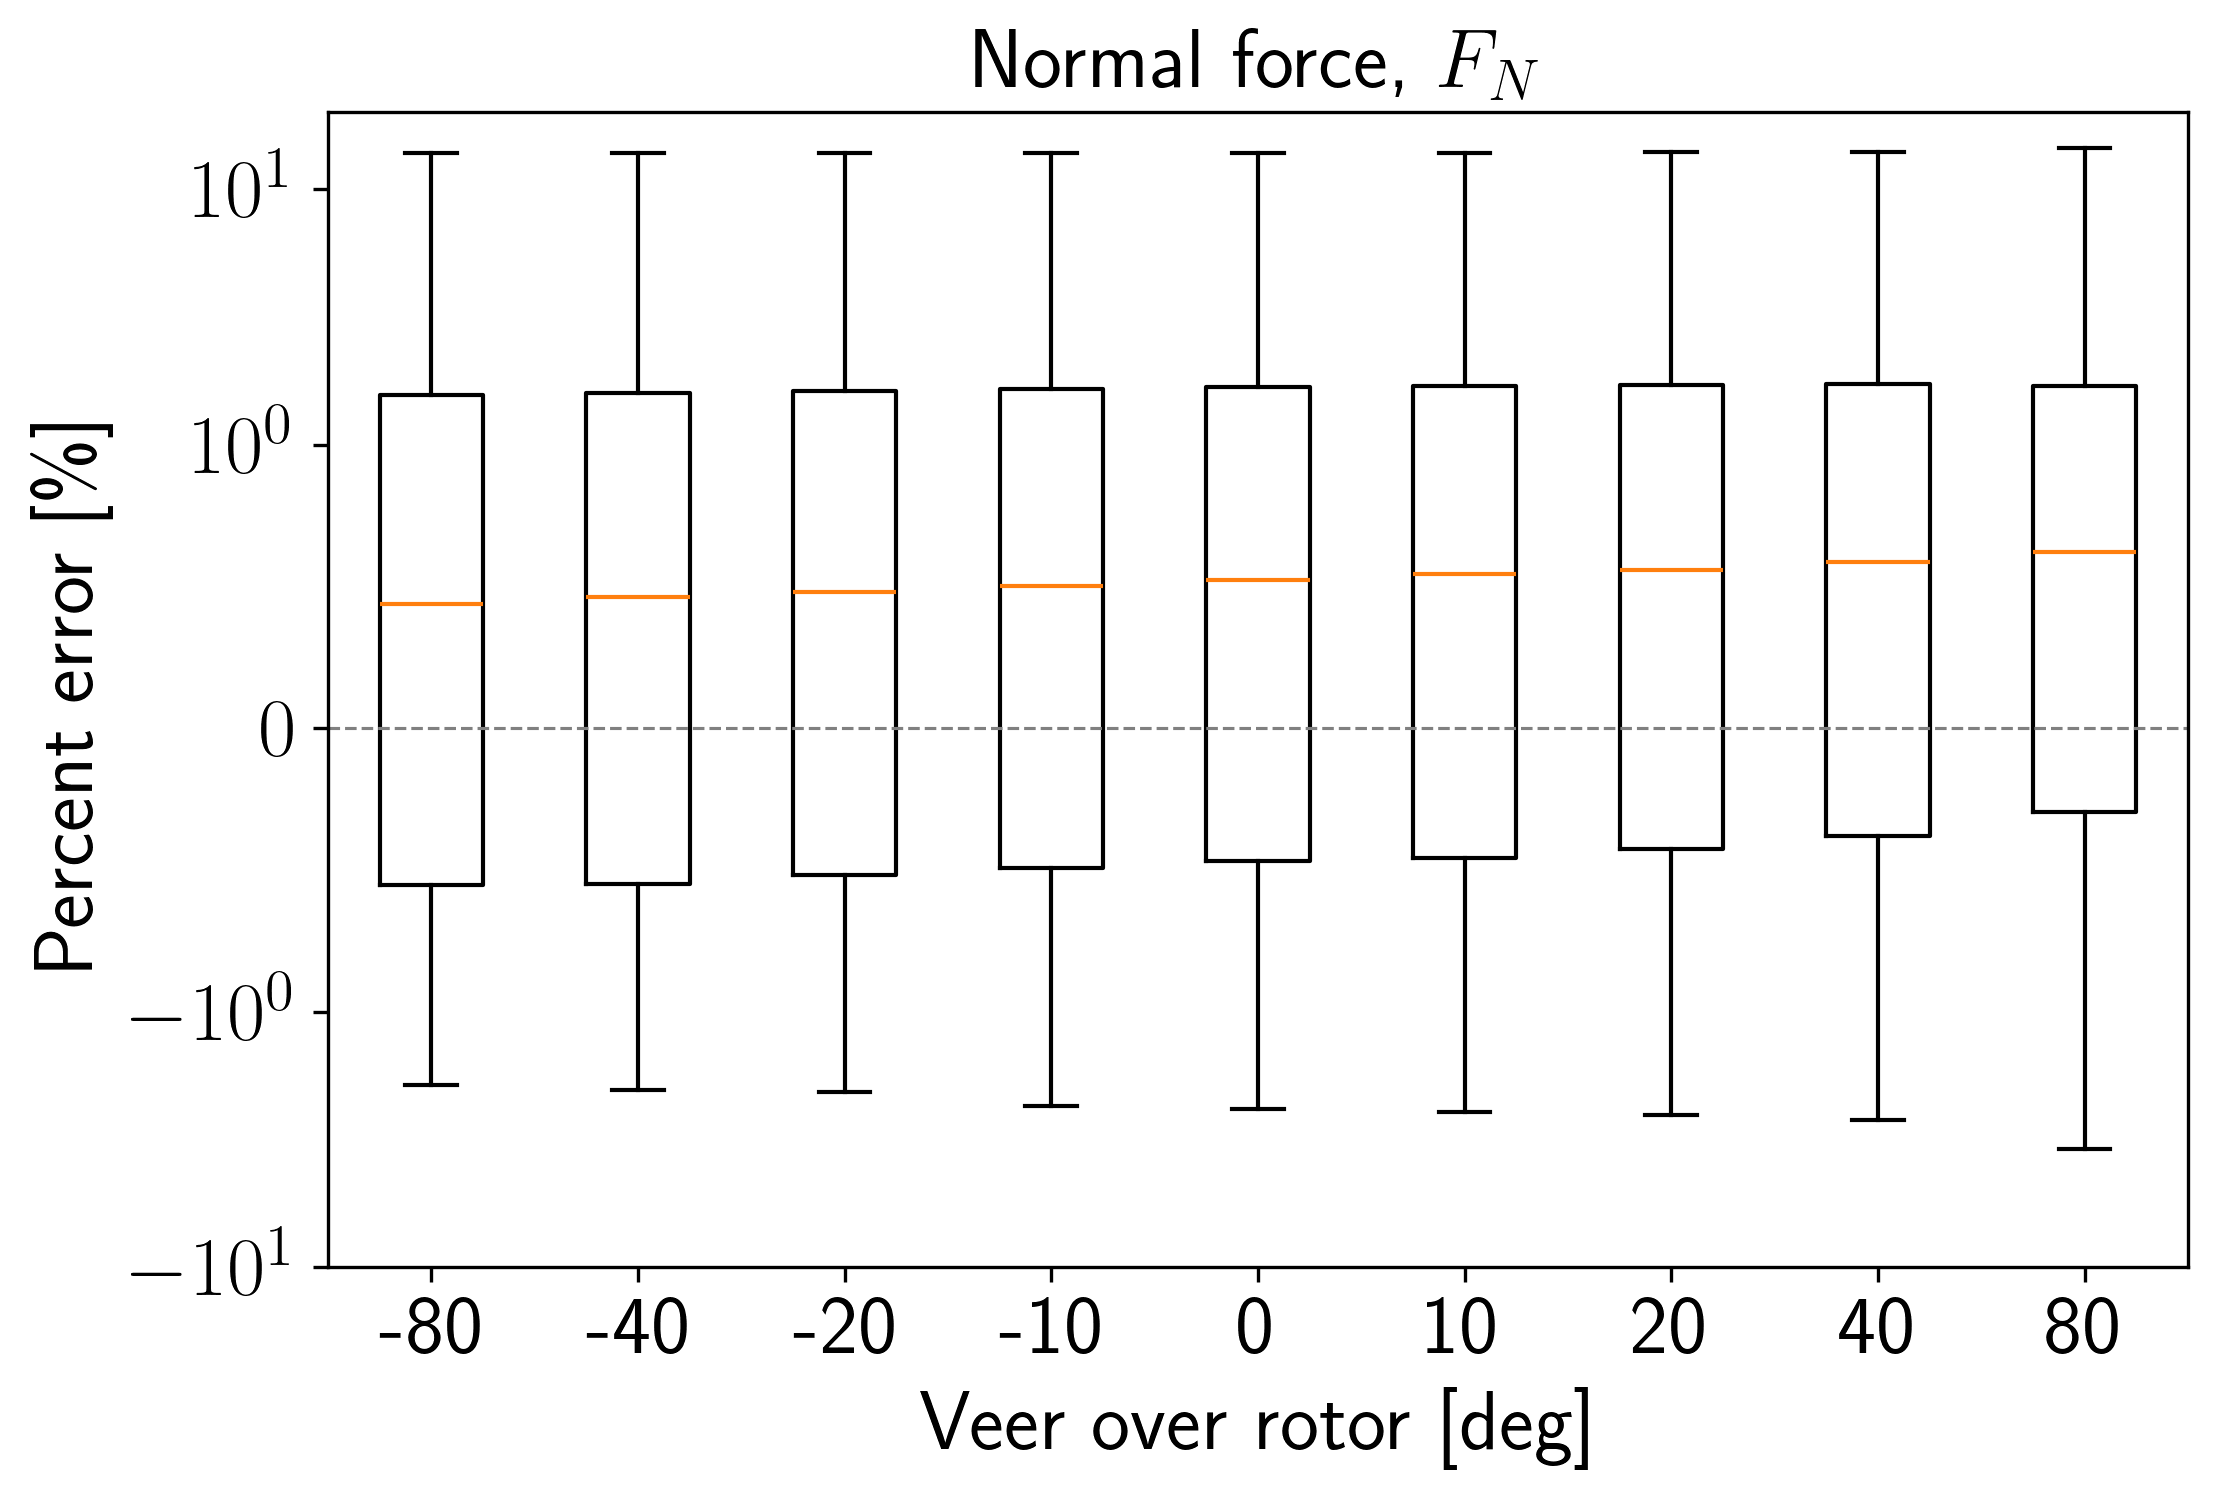

In [23]:
# Normal force

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')

wrf_FN = wrf_L * np.cos(wrf_phi) + wrf_D * np.sin(wrf_phi)

for i in range(len(subset_indices)):
    errors = postproc.per_error(wrf_FN[:,:,subset_indices[i]], wrf_FN_real[:,:,subset_indices[i]])

    errors = errors[np.isfinite(errors)]

    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(errors, [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Normal force, $F_N$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog', linthresh=1)
ax.set_ylim([-10,20])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

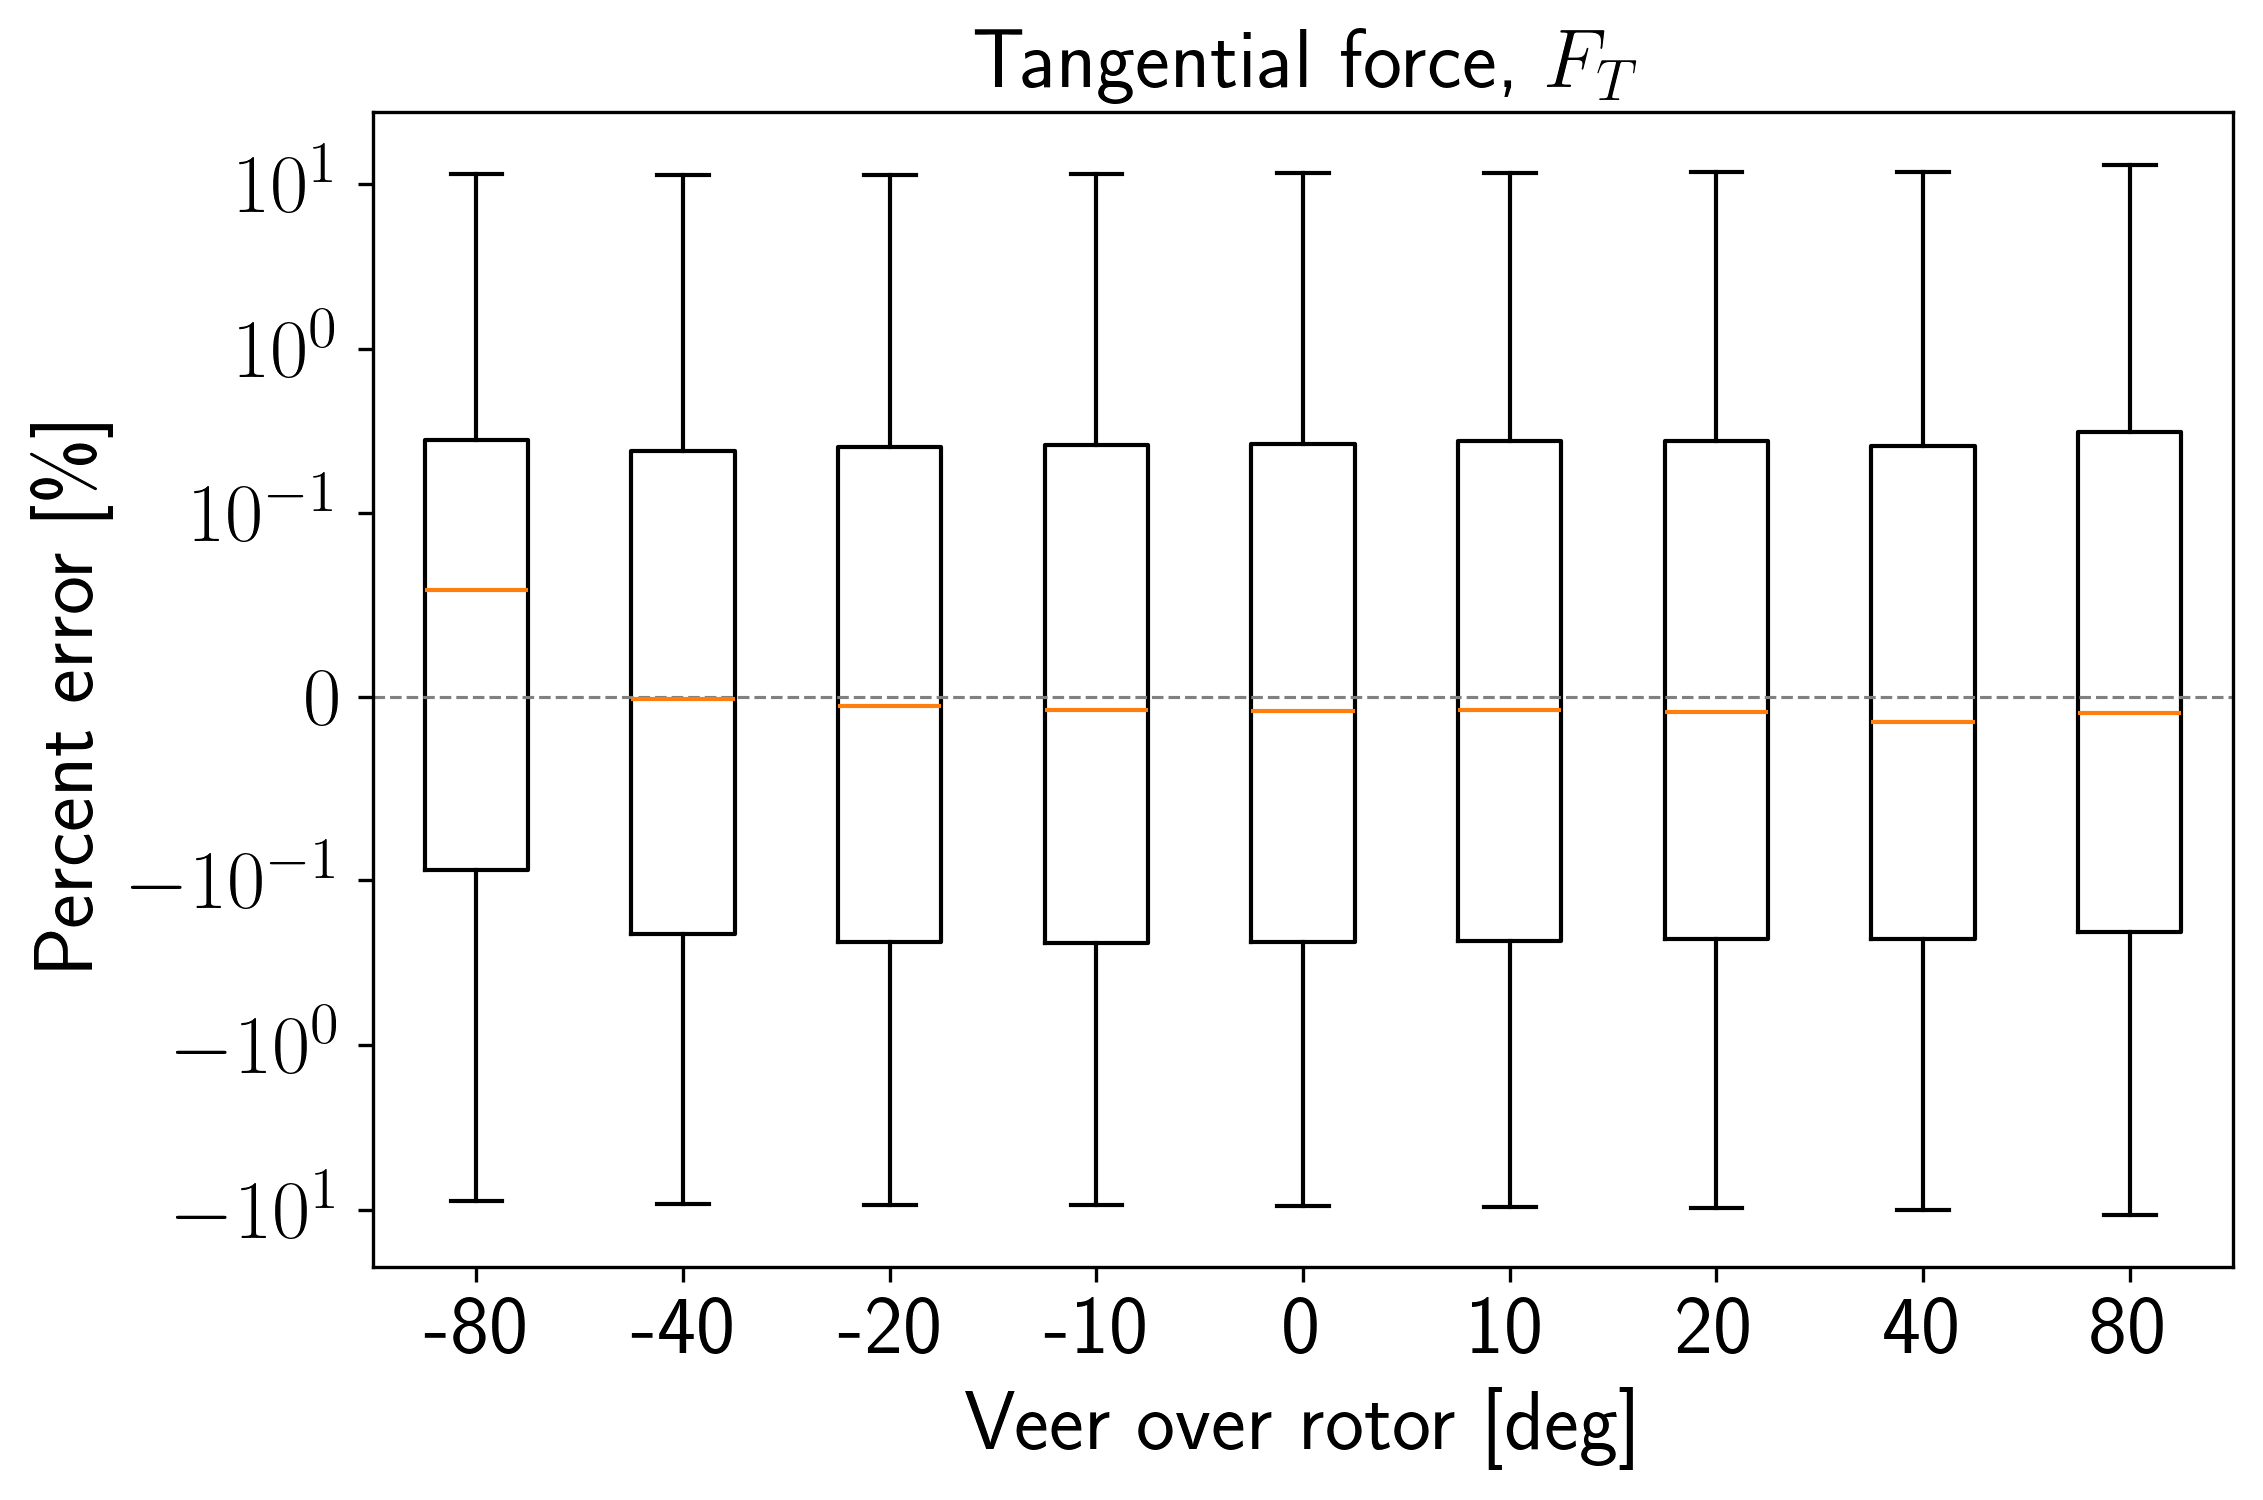

In [24]:
# Tangential force

Q1 = np.zeros_like(subset_indices,dtype='float')
Q2 = np.zeros_like(subset_indices,dtype='float')
Q3 = np.zeros_like(subset_indices,dtype='float')
Q4 = np.zeros_like(subset_indices,dtype='float')
Q5 = np.zeros_like(subset_indices,dtype='float')

wrf_FT = wrf_L * np.sin(wrf_phi) - wrf_D * np.cos(wrf_phi)

for i in range(len(subset_indices)):
    errors = postproc.per_error(wrf_FT[:,:,subset_indices[i]], wrf_FT_real[:,:,subset_indices[i]])

    errors = errors[np.isfinite(errors)]

    Q1[i], Q2[i], Q3[i], Q4[i], Q5[i] = np.quantile(errors, [0,0.25,0.5,0.75,1])

#Plot
N = len(Q1)

box_data = []
for i in range(N):
    box = {
        'med': Q3[i],
        'q1': Q2[i],
        'q3': Q4[i],
        'whislo': Q1[i],
        'whishi': Q5[i],
        'fliers': []
    }
    box_data.append(box)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(box_data, showfliers=False)
ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
ax.set_title("Tangential force, $F_T$",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_yscale('symlog',linthresh=1e-1)
# ax.set_ylim([-10,20])
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)

plt.show()

In [25]:
# Thrust

wrf_thr = np.zeros_like(casenames,dtype='float')

sigma = 3/158
dr = (R - rotor.hub_radius)/26

wrf_thr_mat = wrf_FN * dr * sigma

for i in range(len(training)):
    wrf_thr[i] = np.sum(wrf_thr_mat[:,:,i])/1e3

thr_err = postproc.per_error(wrf_thr[subset_indices], wrf_thr_real[subset_indices]/1e3)

In [26]:
# Power

wrf_pow = np.zeros_like(casenames,dtype='float')

r = wrfles_bem[0]['rOverR'] * R

wrf_pow_mat = (wrf_FT.T * r * dr * sigma * wrf_omg[:, np.newaxis, np.newaxis] * 2 * np.pi / 60).T

for i in range(len(training)):
    wrf_pow[i] = np.sum(wrf_pow_mat[:,:,i])/1e6

pow_err = postproc.per_error(wrf_pow[subset_indices], wrf_pow_real[subset_indices]/1e6)

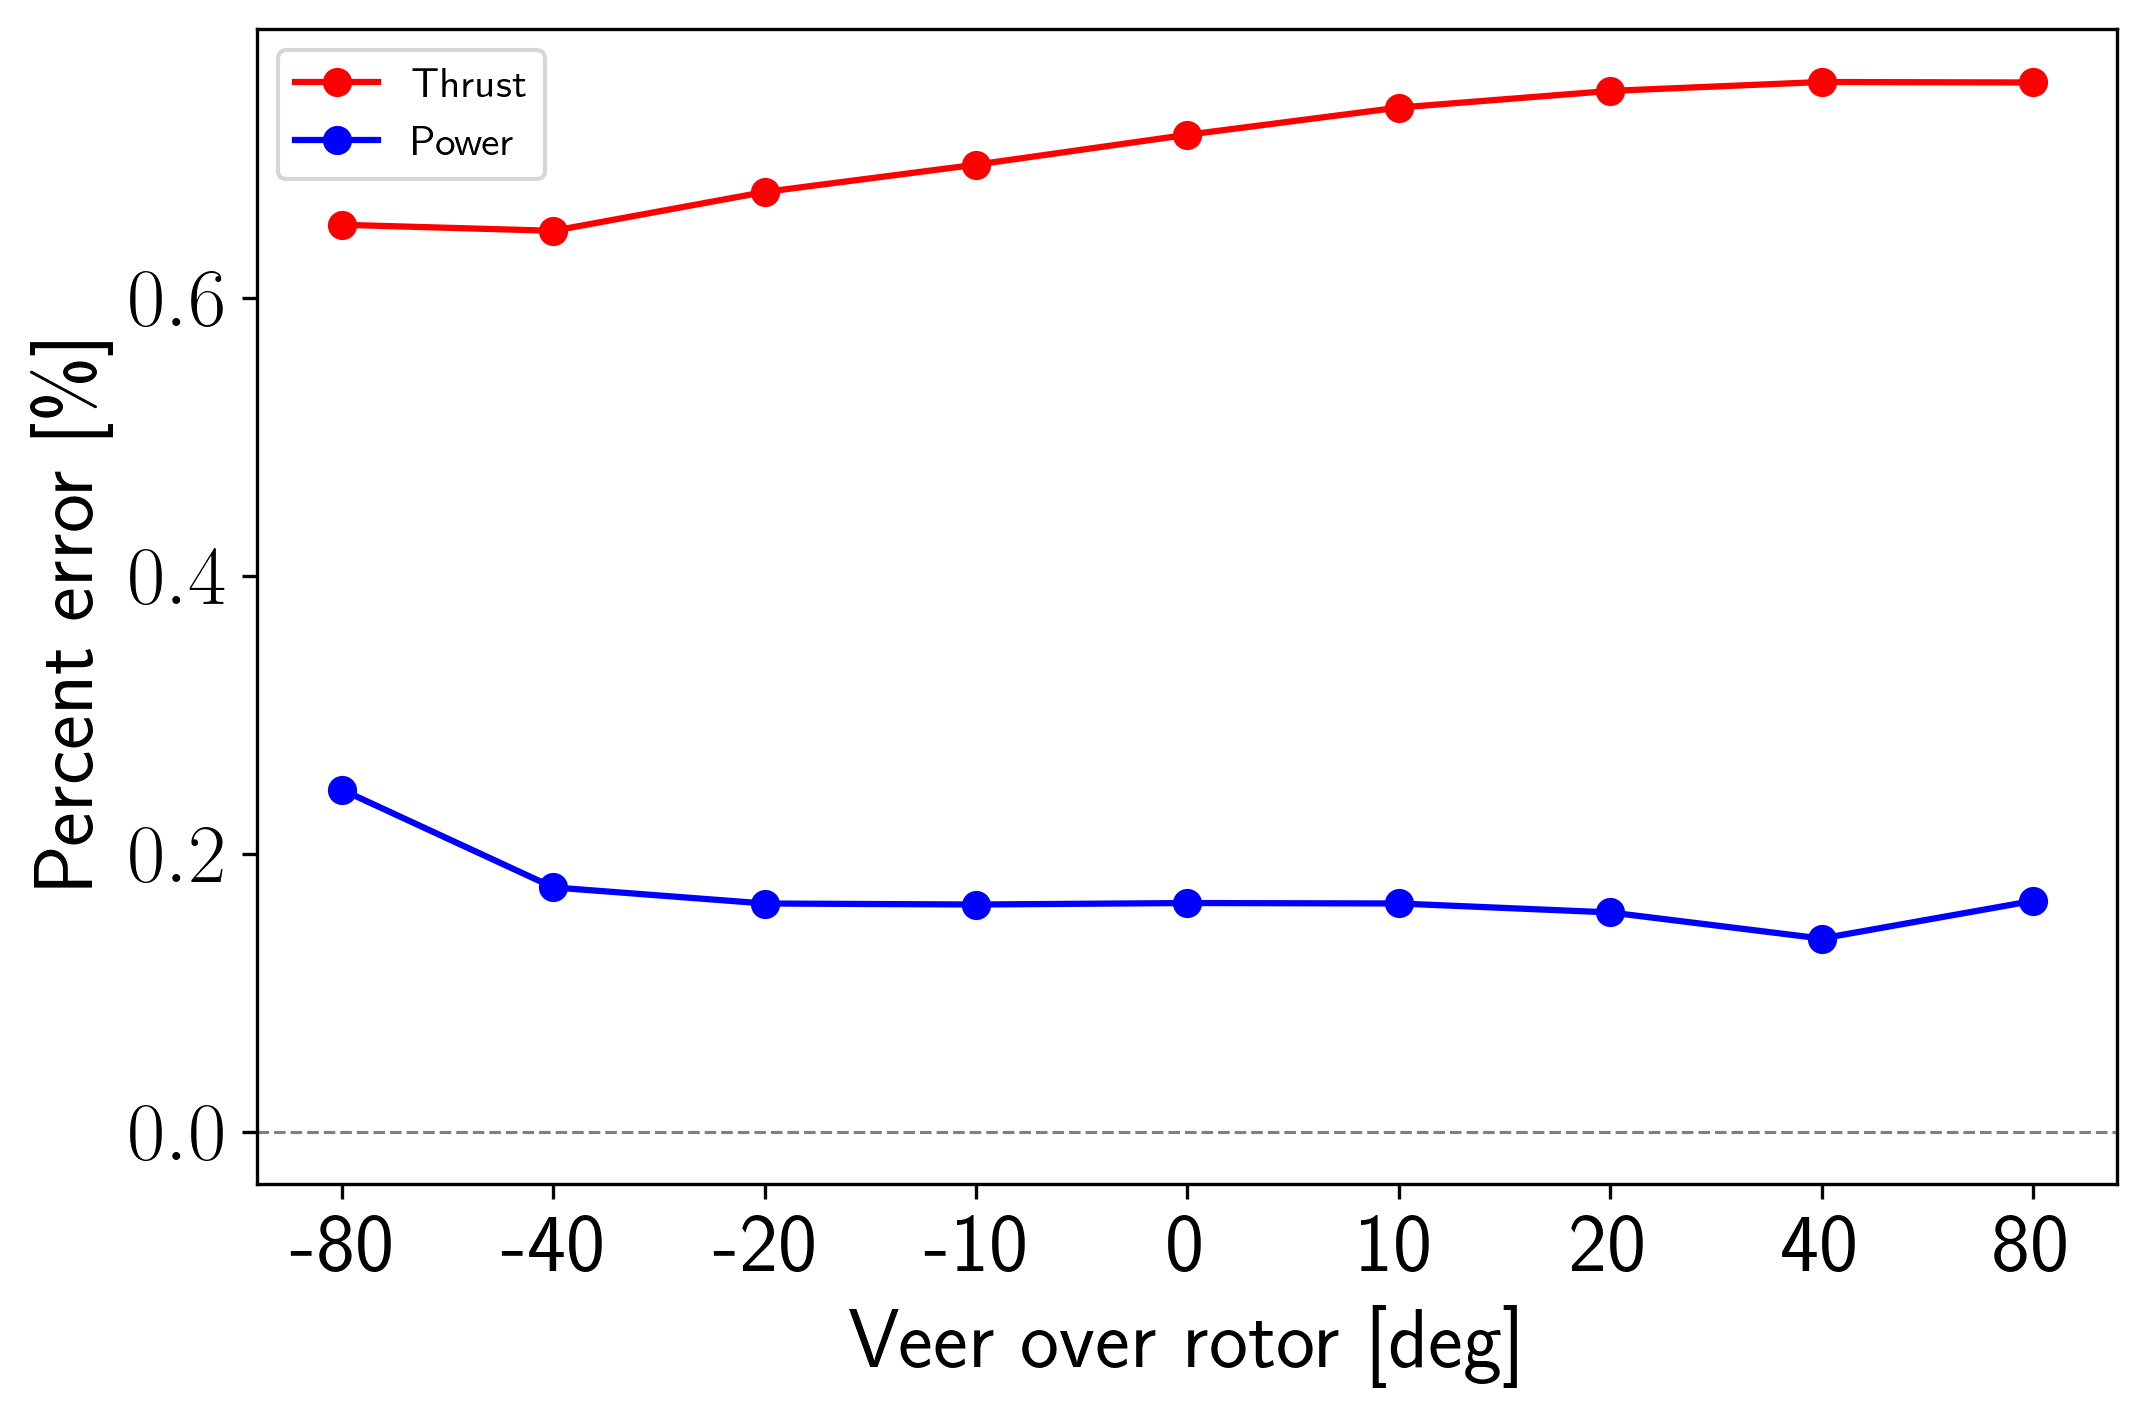

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(thr_err, color='r', label='Thrust', marker='o')
ax.plot(pow_err, color='b', label='Power', marker='o')


ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(subset_indices)-1,len(subset_indices)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
# ax.set_ylim([-1e-1,1])

# ax.set_yscale('symlog',linthresh=1e-4)
# ax.set_ylim([-8e-4,2e-2])

ax.legend()

plt.show()

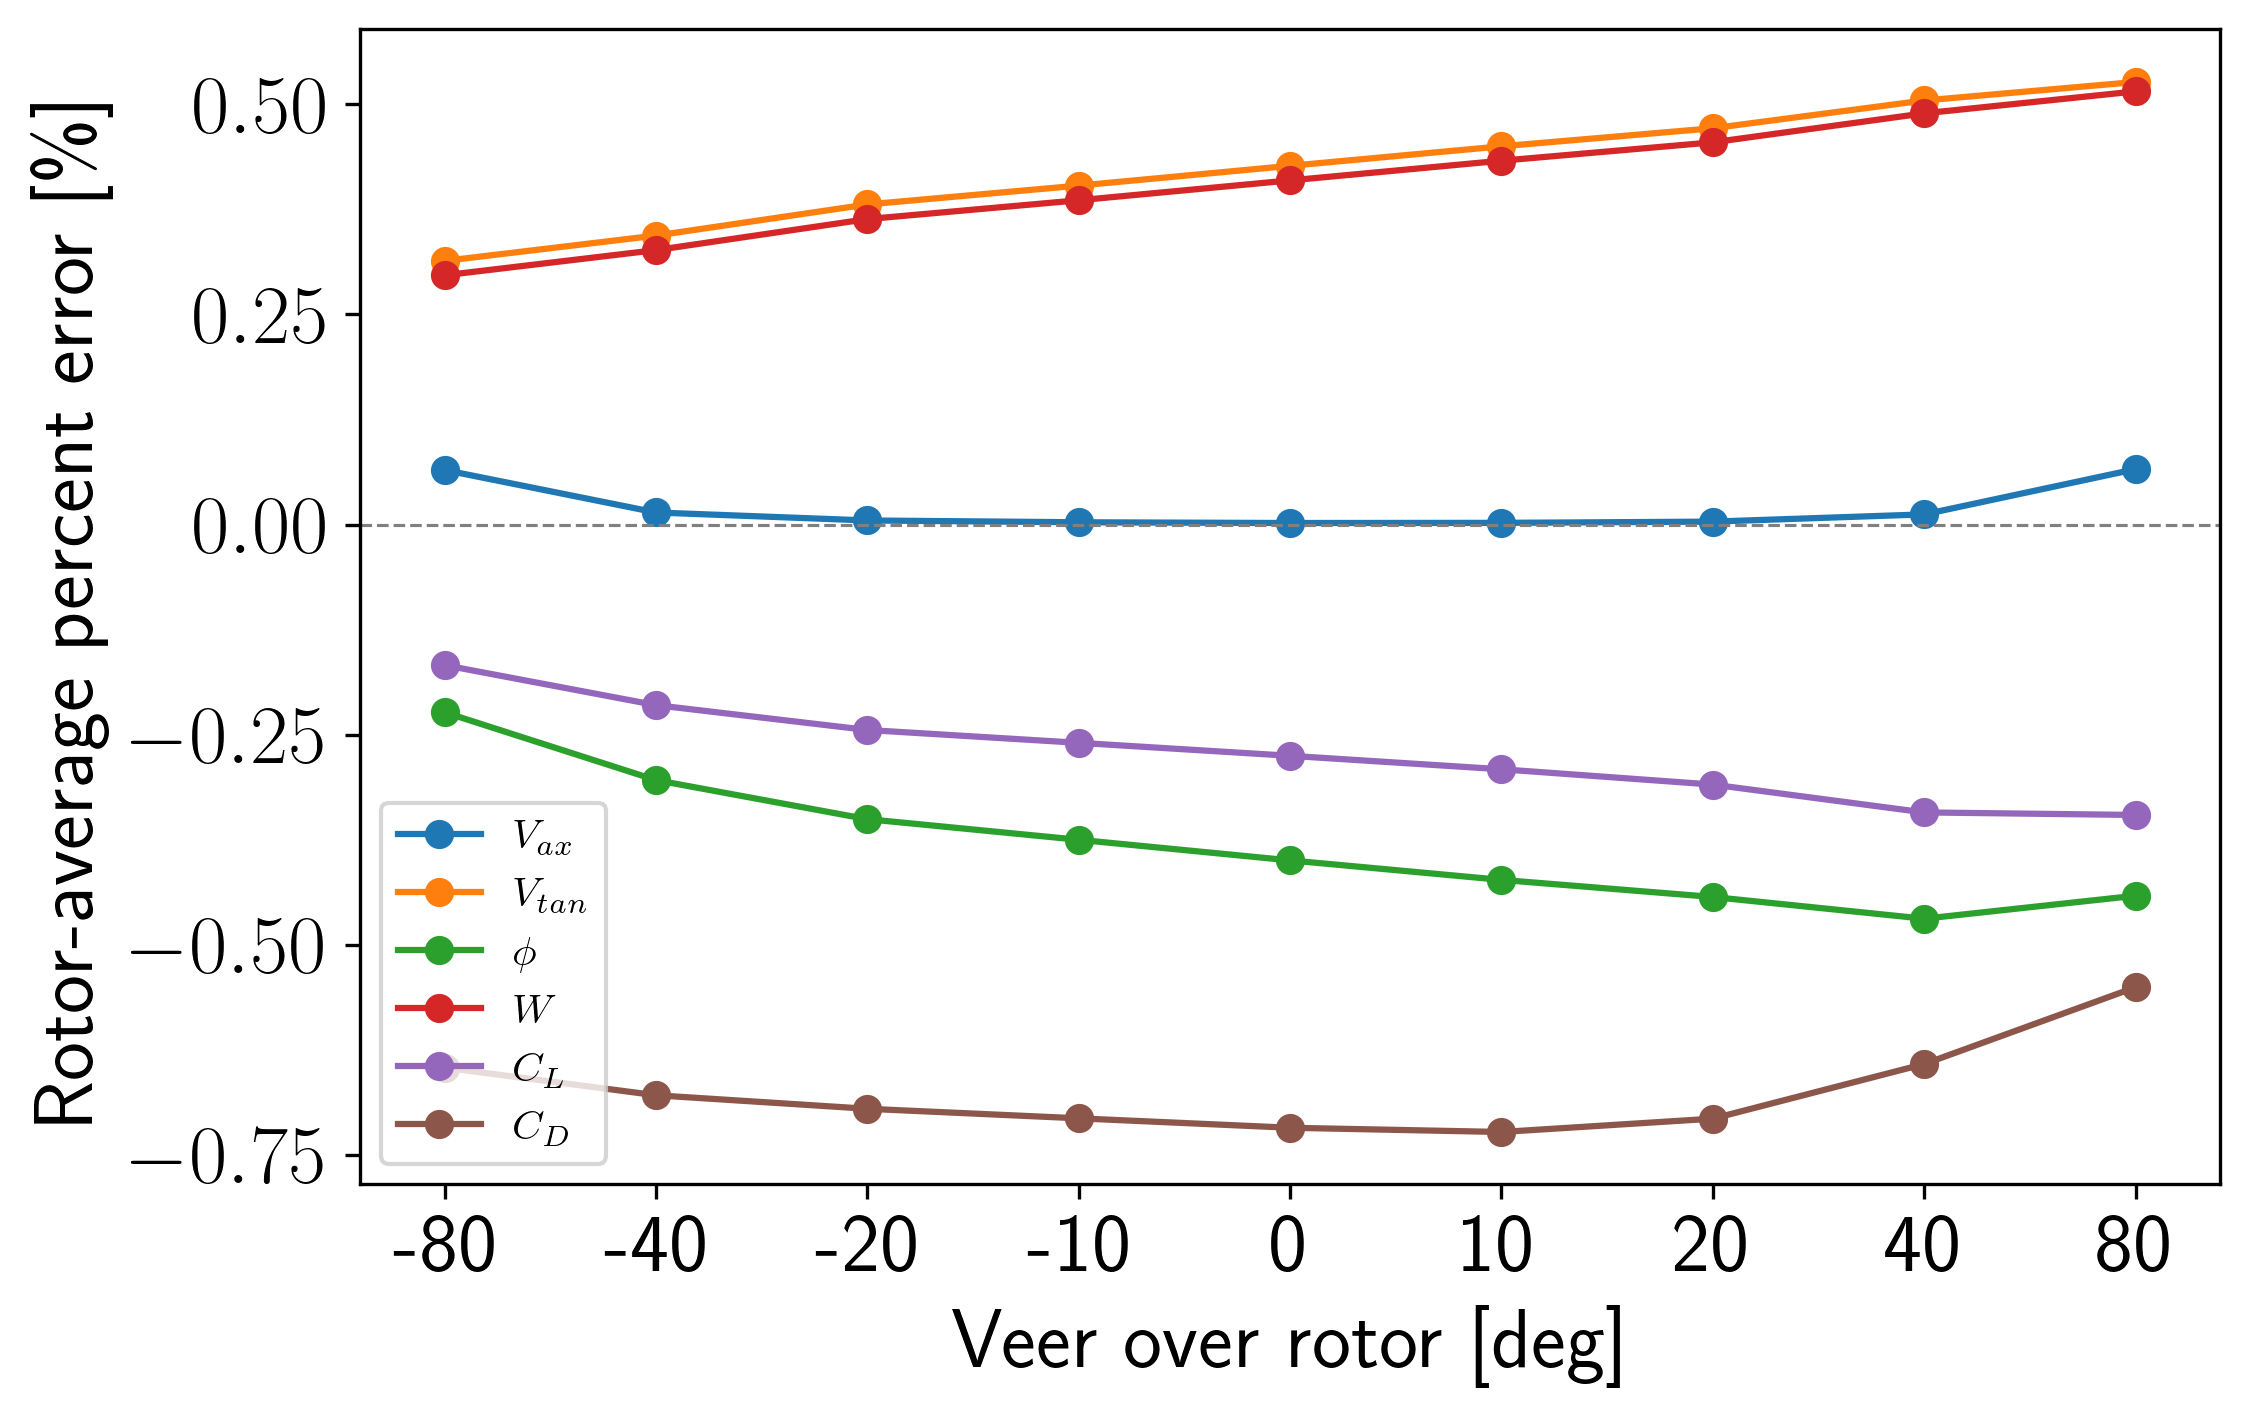

In [28]:
r = wrfles_bem[0]['rOverR']
theta = np.linspace(0, 2*np.pi, wrfles_bem[0]['Nsct'])

colors = sns.color_palette("tab10",len(subset_indices))

RA_vax = np.zeros_like(subset_indices, dtype='float')
RA_vtn = np.zeros_like(subset_indices, dtype='float')
RA_phi = np.zeros_like(subset_indices, dtype='float')
RA_W   = np.zeros_like(subset_indices, dtype='float')
RA_CL  = np.zeros_like(subset_indices, dtype='float')
RA_CD  = np.zeros_like(subset_indices, dtype='float')

for i in range(len(subset_indices)):
    RA_vax[i] = rotor_average(postproc.per_error(wrf_vax[:,:,subset_indices[i]], wrf_vax_real[:,:,subset_indices[i]]), r, theta)
    RA_vtn[i] = rotor_average(postproc.per_error(wrf_vtn[:,:,subset_indices[i]], wrf_vtn_real[:,:,subset_indices[i]]), r, theta)
    RA_phi[i] = rotor_average(postproc.per_error(wrf_phi[:,:,subset_indices[i]], wrf_phi_real[:,:,subset_indices[i]]), r, theta)
    RA_W[i]   = rotor_average(postproc.per_error(wrf_W[:,:,subset_indices[i]], wrf_W_real[:,:,subset_indices[i]]), r, theta)
    CLerrors = postproc.per_error(wrf_CL[:,:,subset_indices[i]], wrf_CL_real[:,:,subset_indices[i]])
    CLerrors[np.isinf(CLerrors)] = 0
    RA_CL[i]  = rotor_average(CLerrors, r, theta)
    RA_CD[i]  = rotor_average(postproc.per_error(wrf_CD[:,:,subset_indices[i]], wrf_CD_real[:,:,subset_indices[i]]), r, theta)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(RA_vax, color=colors[0], label='$V_{ax}$', marker='o')
ax.plot(RA_vtn, color=colors[1], label='$V_{tan}$', marker='o')
ax.plot(RA_phi, color=colors[2], label='$\phi$', marker='o')
ax.plot(RA_W,   color=colors[3], label='$W$', marker='o')
ax.plot(RA_CL,  color=colors[4], label='$C_L$', marker='o')
ax.plot(RA_CD,  color=colors[5], label='$C_D$', marker='o')

ax.set_ylabel("Rotor-average percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(subset_indices)-1,len(subset_indices)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
# ax.set_ylim([-1e-1,1])

ax.legend()

plt.show()

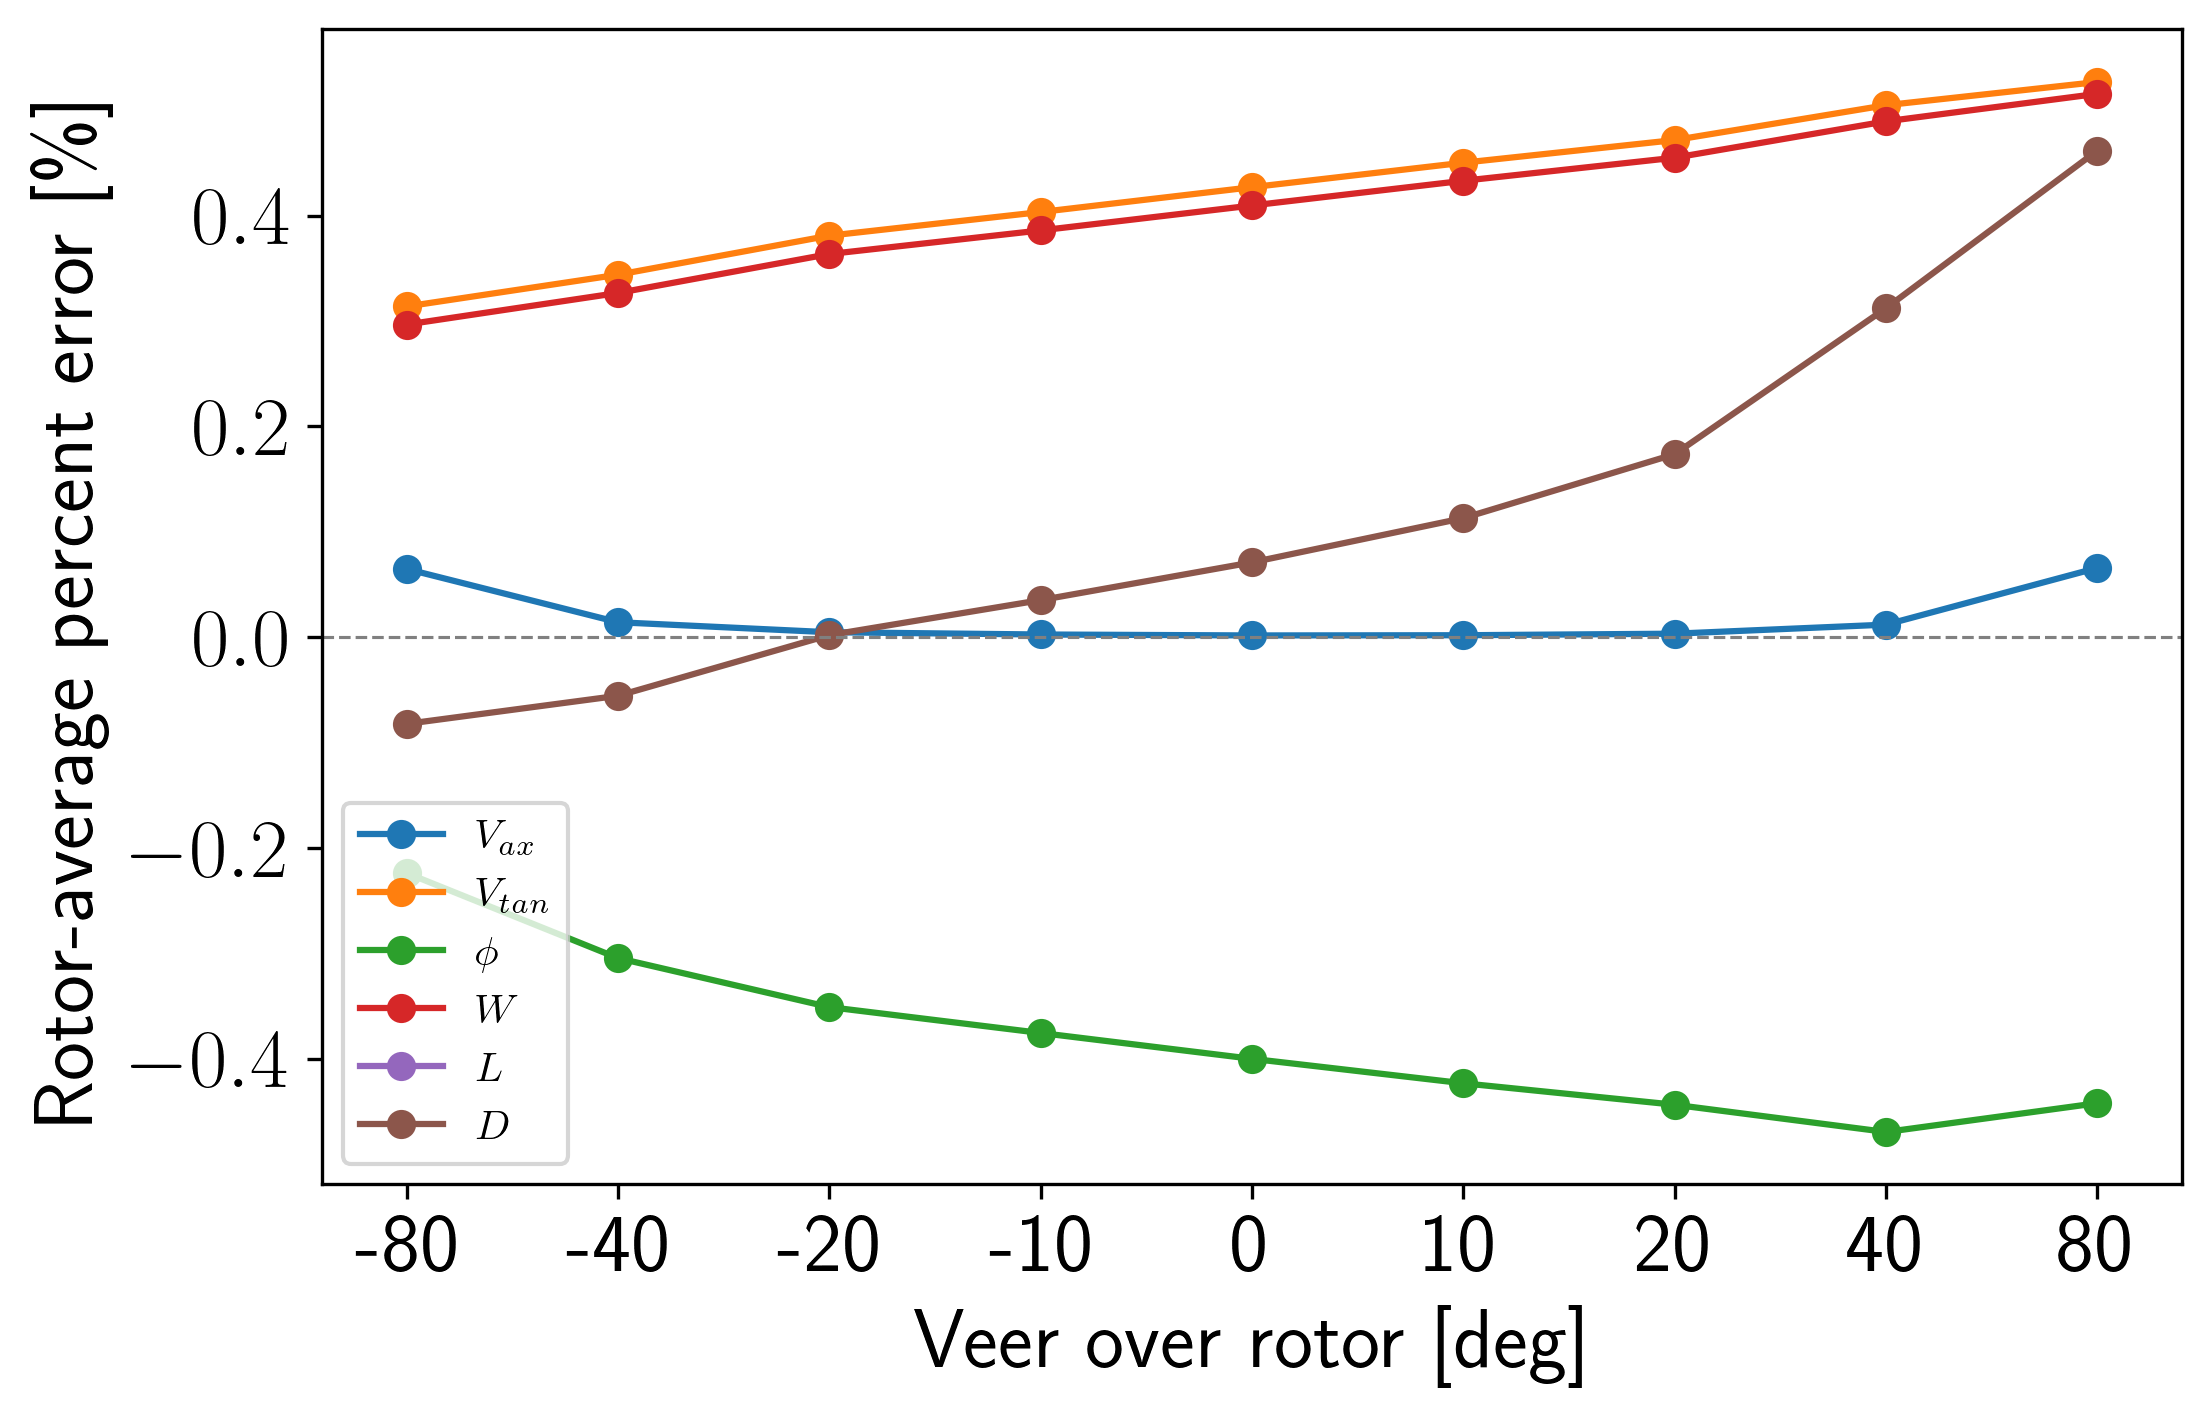

In [29]:
r = wrfles_bem[0]['rOverR']
theta = np.linspace(0, 2*np.pi, wrfles_bem[0]['Nsct'])

colors = sns.color_palette("tab10",len(subset_indices))

RA_vax = np.zeros_like(subset_indices, dtype='float')
RA_vtn = np.zeros_like(subset_indices, dtype='float')
RA_phi = np.zeros_like(subset_indices, dtype='float')
RA_W   = np.zeros_like(subset_indices, dtype='float')
RA_L   = np.zeros_like(subset_indices, dtype='float')
RA_D   = np.zeros_like(subset_indices, dtype='float')

for i in range(len(subset_indices)):
    RA_vax[i] = rotor_average(postproc.per_error(wrf_vax[:,:,subset_indices[i]], wrf_vax_real[:,:,subset_indices[i]]), r, theta)
    RA_vtn[i] = rotor_average(postproc.per_error(wrf_vtn[:,:,subset_indices[i]], wrf_vtn_real[:,:,subset_indices[i]]), r, theta)
    RA_phi[i] = rotor_average(postproc.per_error(wrf_phi[:,:,subset_indices[i]], wrf_phi_real[:,:,subset_indices[i]]), r, theta)
    RA_W[i]   = rotor_average(postproc.per_error(wrf_W[:,:,subset_indices[i]], wrf_W_real[:,:,subset_indices[i]]), r, theta)
    RA_L[i]   = rotor_average(postproc.per_error(wrf_L[:,:,subset_indices[i]], wrf_L_real[:,:,subset_indices[i]]), r, theta)
    RA_D[i]   = rotor_average(postproc.per_error(wrf_D[:,:,subset_indices[i]], wrf_D_real[:,:,subset_indices[i]]), r, theta)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(RA_vax, color=colors[0], label='$V_{ax}$', marker='o')
ax.plot(RA_vtn, color=colors[1], label='$V_{tan}$', marker='o')
ax.plot(RA_phi, color=colors[2], label='$\phi$', marker='o')
ax.plot(RA_W,   color=colors[3], label='$W$', marker='o')
ax.plot(RA_L,   color=colors[4], label='$L$', marker='o')
ax.plot(RA_D,   color=colors[5], label='$D$', marker='o')

ax.set_ylabel("Rotor-average percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(subset_indices)-1,len(subset_indices)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
# ax.set_ylim([-1e-1,1])

ax.legend()

plt.show()

## Evaluate error in MITRotor with induction model turned off

In [30]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, ConstantInduction

In [31]:
rotor = IEA10MW()

mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

mit_T = np.zeros_like(subset_indices, dtype='float')
mit_P = np.zeros_like(subset_indices, dtype='float')

mit_CL = np.zeros_like(wrf_CL[:,:,subset_indices], dtype='float')
mit_CD = np.zeros_like(wrf_CD[:,:,subset_indices], dtype='float')

mit_L = np.zeros_like(wrf_CL[:,:,subset_indices], dtype='float')
mit_D = np.zeros_like(wrf_CD[:,:,subset_indices], dtype='float')

mit_FN = np.zeros_like(wrf_CL[:,:,subset_indices], dtype='float')
mit_FT = np.zeros_like(wrf_CD[:,:,subset_indices], dtype='float')

mit_W = np.zeros_like(wrf_W[:,:,subset_indices], dtype='float')
mit_Vax = np.zeros_like(wrf_vax[:,:,subset_indices], dtype='float')
mit_Vtn = np.zeros_like(wrf_vtn[:,:,subset_indices], dtype='float')
mit_phi = np.zeros_like(wrf_phi[:,:,subset_indices], dtype='float')
mit_U = np.zeros_like(wrf_phi[:,:,subset_indices], dtype='float')

for count in range(len(subset_indices)):

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R,Rhub=rotor.hub_radius), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0.0), tangential_induction_model=NoTangentialInduction(),index = subset_indices[count])

    tsr = wrf_tsr[subset_indices[count]]

    sol = bem(0, tsr, 0, U = U_loc[:,:,subset_indices[count]], wdir=dir_loc[:,:,subset_indices[count]], index = subset_indices[count], v_inf=Uhub[subset_indices[count]])

    mit_T[count] = sol.thrust()/1e3
    mit_P[count] = sol.power()/1e6

    mit_cot[count] = sol.Ct()
    mit_cop[count] = sol.Cp()

    mit_CL[:,:,count] = sol.Cl('sector')
    mit_CD[:,:,count] = sol.Cd('sector')

    mit_L[:,:,count] = sol.FL()
    mit_D[:,:,count] = sol.FD()

    mit_FN[:,:,count] = sol.FN()
    mit_FT[:,:,count] = sol.FT()

    mit_W[:,:,count] = sol.W('sector')
    mit_Vax[:,:,count] = sol.Vax('sector')
    mit_Vtn[:,:,count] = sol.Vtan('sector')
    mit_phi[:,:,count] = sol.phi('sector')
    mit_U[:,:,count] = sol.U('sector')

    iters[count] = sol.niter

iters

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

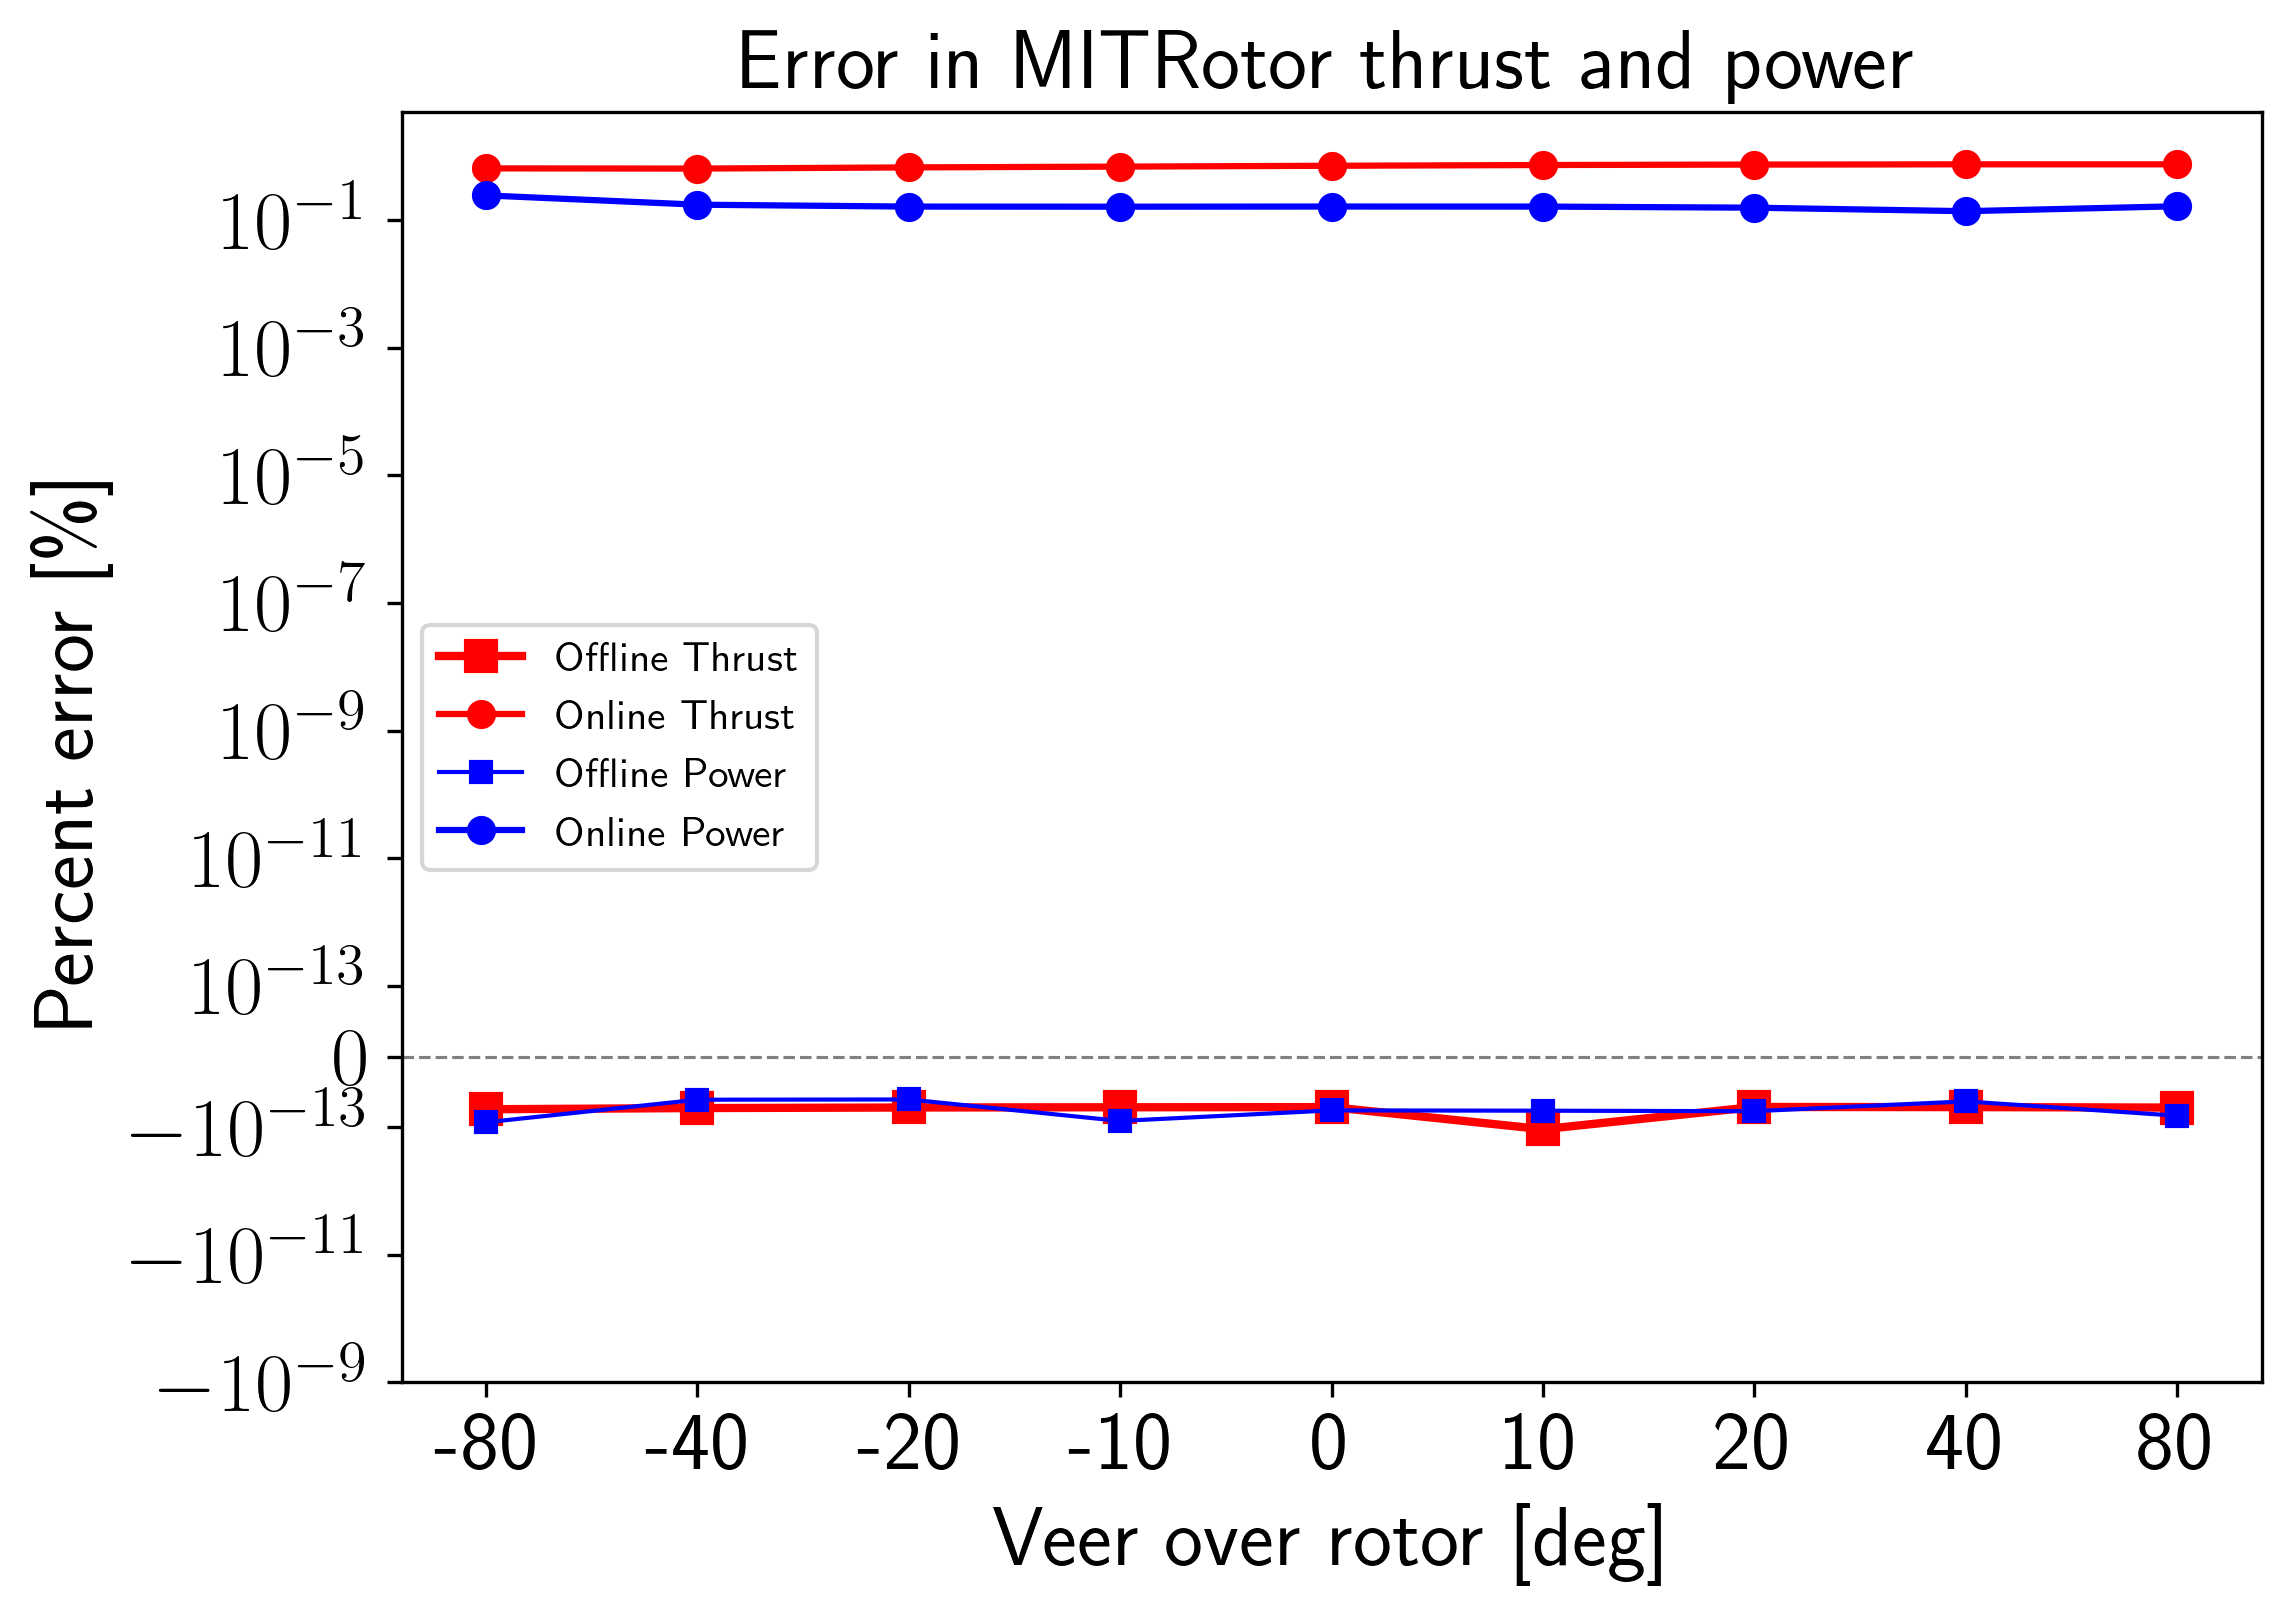

In [63]:
fig, ax = plt.subplots(figsize=(8, 5.5))

mit_offline_err_T = postproc.per_error(mit_T, wrf_thr[subset_indices])
mit_online_err_T  = postproc.per_error(mit_T, wrf_thr_real[subset_indices]/1e3)

mit_offline_err_P = postproc.per_error(mit_P, wrf_pow[subset_indices])
mit_online_err_P  = postproc.per_error(mit_P, wrf_pow_real[subset_indices]/1e6)

ax.plot(mit_offline_err_T, color='r', linewidth=2,label='Offline Thrust', marker='s',markersize=7)
ax.plot(mit_online_err_T, color='r', label='Online Thrust', marker='o')

ax.plot(mit_offline_err_P, color='b', linewidth=1,label='Offline Power', marker='s',markersize=5)
ax.plot(mit_online_err_P, color='b', label='Online Power', marker='o')

ax.set_ylabel("Percent error [\%]",fontsize=fontsize)
xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax.set_xticks(np.linspace(0,len(subset_indices)-1,len(subset_indices)))
ax.set_xticklabels(xaxislabels, fontsize=fontsize)
ax.set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax.set_title('Error in MITRotor thrust and power',fontsize=fontsize)
ax.axhline(0, linestyle='--', color='grey', linewidth = 0.75)
ax.set_yscale('symlog',linthresh=1e-13)
ax.set_ylim([-1e-9,5])

ax.legend(loc='center left')

plt.show()